**Cell 1**

# Sentiment Analysis: From Bag-of-Words to Neural Classifiers

---

> ### 📋 Assignment
> You will build a complete sentiment classification pipeline on the **IMDB Movie Review** dataset — 50,000 reviews labelled positive or negative.
>
> **Part 1** uses classical machine learning on **binary one-hot vectors** — the simplest possible text representation.
> **Part 2** introduces neural sequence models for NLP. The boilerplate (data loading, vocabulary, training loop, evaluation) is **fully provided and pre-written**. Your job is to:
> 1. Build the **model architectures** (`### CODE HERE ###` inside `nn.Module` classes)
> 2. Write **interpretation and reflection** cells
>
> **Cells marked `# ── PROVIDED ──` carry no marks** — just run them.
> **Cells marked `### CODE HERE ###` carry marks** — these are yours to complete.
>
> Use `random_state=42` wherever accepted.

---

## What You Will Build

| Part | Approach | Key Idea |
|------|----------|----------|
| **Part 1** | Classical ML — LR, Naive Bayes, SVM, Random Forest | Binary one-hot vectors (word present/absent) |
| **Part 2A** | Vanilla RNN | Reads tokens sequentially; hidden state carries context |
| **Part 2B** | LSTM | Gated memory solves long-range forgetting |
| **Part 2C** | Bidirectional LSTM + FastText embeddings | Both-direction context + pre-trained word meaning |
| **Part 2D** | Cross-Attention Classifier | Every token attends to every other — no sequential bottleneck |

**Total Marks: 100** (Part 1: 45 | Part 2: 55)

### The Central Question
> *Can a model reading `"the film is not as bad as critics claimed"` correctly identify it as **positive**?*
>
> A one-hot vector sees `bad` and `critics` as present — and guesses *negative*. A neural model reading the full sentence in order has a fighting chance. An attention model can show you exactly which words it focused on.

---

**Cell 2**

# PART 1: Classical Sentiment Classification

## Context

The IMDB dataset contains 50,000 movie reviews — 25,000 for training, 25,000 for testing, perfectly balanced between positive and negative.

Reviews average **~230 words** — long enough that word order and negation genuinely matter. In this part, you will represent each review as a **binary one-hot vector**: a vector of 0s and 1s where a 1 simply means a word appeared in the review, and 0 means it did not. Frequency is ignored entirely — `"masterpiece"` appearing once and `"bad"` appearing ten times both become 1.

This is intentionally the simplest possible text representation. It sets a realistic ceiling that the neural models in Part 2 need to meaningfully exceed. You will see exactly where this representation breaks down.

**Cell 3**

## Stage 1: Data Loading  <font color="red">**[4 marks]**</font>

**What to do:**
- The libraries below are pre-imported. Add anything else you need.
- Load the IMDB dataset using `load_dataset('imdb')` from HuggingFace.
- Extract train texts, test texts, and their labels into plain Python lists.
- Print the number of examples and class distribution.

In [2]:
# Cell 4

# Core data, plotting, and scikit-learn imports used throughout Part 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [5]:
# Cell 5

# Load the IMDB dataset from Hugging Face
dataset = load_dataset("stanfordnlp/imdb")

# Convert HF columns to plain Python lists
train_texts = list(dataset["train"]["text"])
train_labels = list(dataset["train"]["label"])
test_texts = list(dataset["test"]["text"])
test_labels = list(dataset["test"]["label"])

# Convert labels to NumPy arrays for metric calculations and plotting
y_train = np.array(train_labels)
y_test = np.array(test_labels)

In [9]:
# Cell 6

# Print number of examples and label distribution

# Show how many reviews are in each split
print("Training set size:", len(train_texts))
print("Test set size:", len(test_texts))
print()

# Show the training label balance
print("Training label distribution:")
print("Negative (0):", int((y_train == 0).sum()))
print("Positive (1):", int((y_train == 1).sum()))
print()

# Show the test label balance
print("Test label distribution:")
print("Negative (0):", int((y_test == 0).sum()))
print("Positive (1):", int((y_test == 1).sum()))

Training set size: 25000
Test set size: 25000

Training label distribution:
Negative (0): 12500
Positive (1): 12500

Test label distribution:
Negative (0): 12500
Positive (1): 12500


**Cell 7**

## Stage 2: Data Understanding  <font color="red">**[8 marks]**</font>

**Cell 8**

### 2.1 Class Distribution  <font color="red">[1 mark]</font>

Plot a bar chart of positive vs negative counts in the training set.

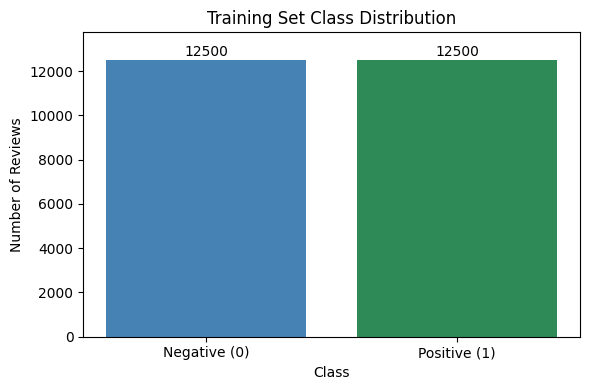

In [11]:
# Cell 9

# Count how many training reviews belong to each class
class_counts = [int((y_train == 0).sum()), int((y_train == 1).sum())]
class_labels = ["Negative (0)", "Positive (1)"]

# Plot a clear bar chart with explicit class labels
plt.figure(figsize=(6, 4))
bars = plt.bar(class_labels, class_counts, color=["steelblue", "seagreen"])
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Reviews")
plt.ylim(0, max(class_counts) * 1.1)

# Add the exact count above each bar for readability
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 50, f"{int(height)}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

**Cell 10**

### 2.2 Review Length Distribution  <font color="red">[2 marks]</font>

Compute word count per training review. Plot a histogram and print the mean, median, and 95th percentile length.
Also plot lengths **separately for positive and negative reviews** using overlapping histograms.

Mean review length: 233.79
Median review length: 174.0
95th percentile review length: 598.0


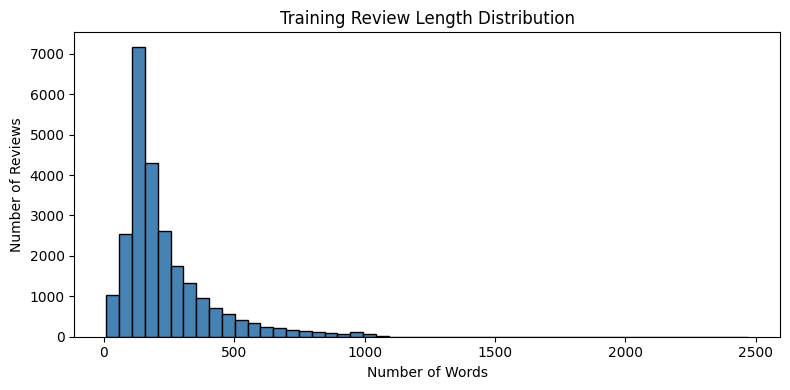

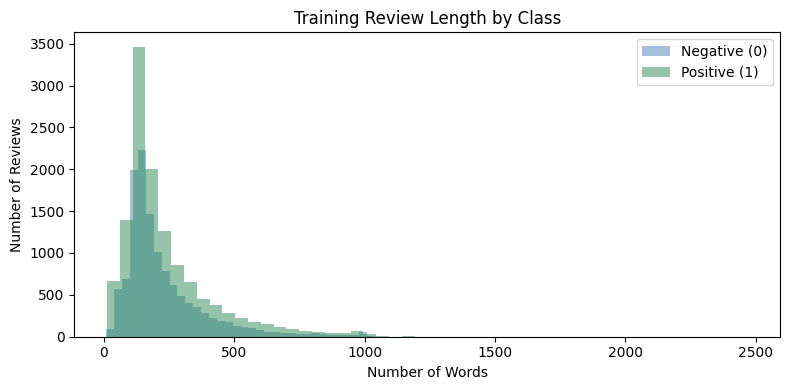

In [ ]:
# Cell 11

# Compute word counts for each training review
train_lengths = [len(text.split()) for text in train_texts]

# Print summary statistics for review length
print("Mean review length:", round(np.mean(train_lengths), 2))
print("Median review length:", round(np.median(train_lengths), 2))
print("95th percentile review length:", round(np.percentile(train_lengths, 95), 2))

# Plot the overall length distribution
plt.figure(figsize=(8, 4))
plt.hist(train_lengths, bins=50, color="steelblue", edgecolor="black")
plt.title("Training Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

# Split lengths by class for overlapping histograms
positive_lengths = [len(text.split()) for text, label in zip(train_texts, y_train) if label == 1]
negative_lengths = [len(text.split()) for text, label in zip(train_texts, y_train) if label == 0]

# Plot positive and negative length distributixons together
plt.figure(figsize=(8, 4))
plt.hist(negative_lengths, bins=50, alpha=0.5, label="Negative (0)", color="steelblue")
plt.hist(positive_lengths, bins=50, alpha=0.5, label="Positive (1)", color="seagreen")
plt.title("Training Review Length by Class")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.legend()
plt.tight_layout()
plt.show()

**Cell 12**

### 2.3 Sample Reviews  <font color="red">[1 mark]</font>

Print the first 200 characters of one positive and one negative review. Note any HTML artefacts you see.

In [14]:
# Cell 13

# Pick one positive and one negative review from the training split
positive_review = next(text for text, label in zip(train_texts, y_train) if label == 1)
negative_review = next(text for text, label in zip(train_texts, y_train) if label == 0)

# Show the first 200 characters so the raw text format is easy to inspect
print('Positive review (first 200 chars):')
print(positive_review[:200])
print()
print('Negative review (first 200 chars):')
print(negative_review[:200])
print()
# Note common HTML artefacts that can appear in IMDB review text
html_artifacts = []
for artifact in ['<br />', '<br>', '&quot;', '&#39;']:
    if artifact in positive_review or artifact in negative_review:
        html_artifacts.append(artifact)

if html_artifacts:
    print('HTML artefacts seen:', ', '.join(html_artifacts))
else:
    print('HTML artefacts seen: none in these two samples')

Positive review (first 200 chars):
Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emo

Negative review (first 200 chars):
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev

HTML artefacts seen: <br />


**Cell 14**

### 2.4 Top Words by Class  <font color="red">[2 marks]</font>

Fit a `CountVectorizer` (with `stop_words='english'`) on training data only.
Plot the top 20 most frequent words for positive reviews and negative reviews side by side.

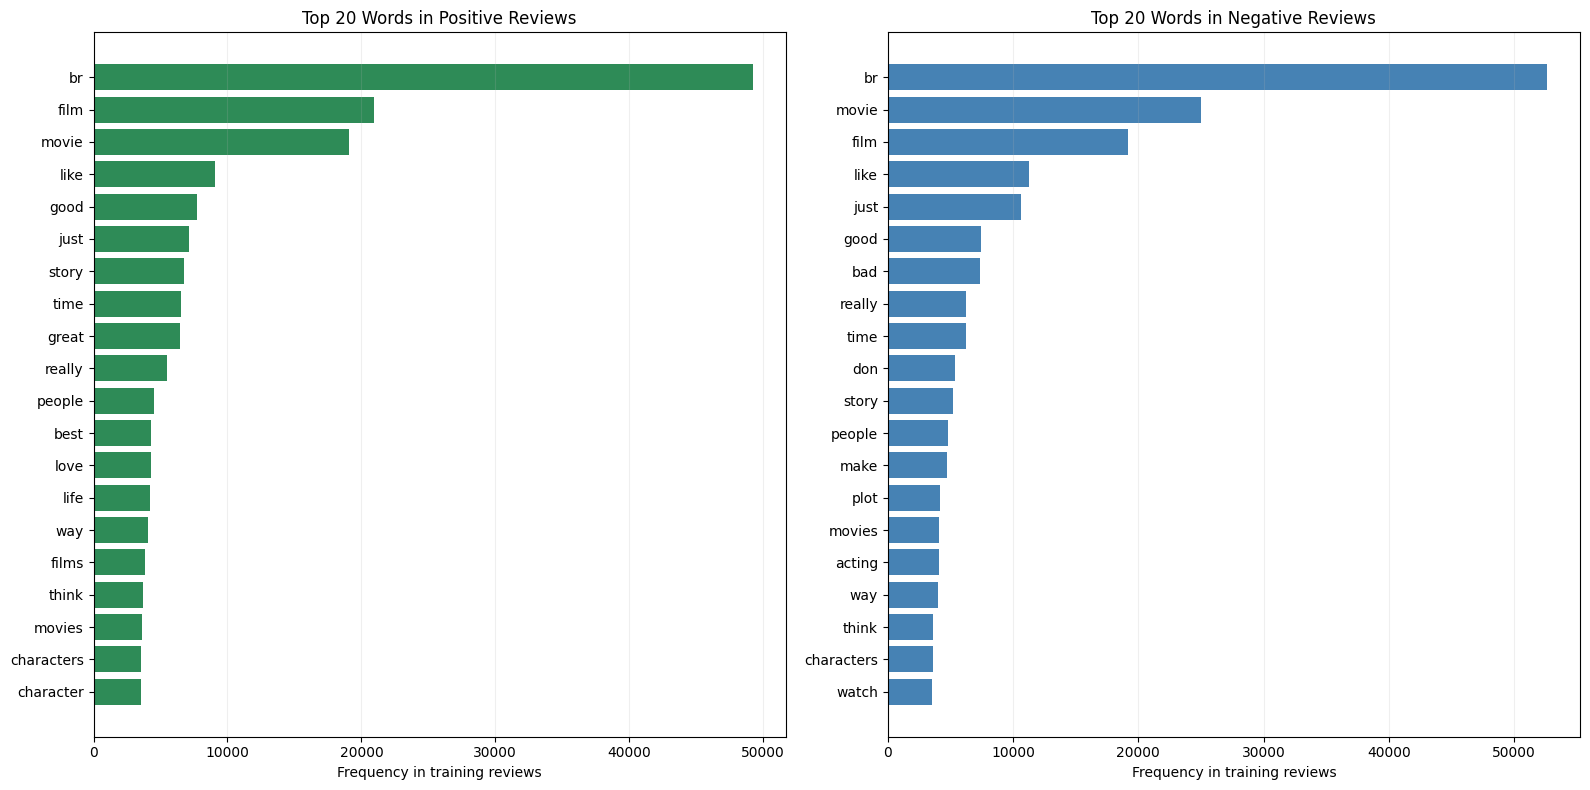

In [15]:
# Cell 15

# Fit a CountVectorizer on the full training split only
vectorizer = CountVectorizer(stop_words='english')
X_train_counts = vectorizer.fit_transform(train_texts)
terms = np.array(vectorizer.get_feature_names_out())

# Aggregate word counts separately for positive and negative reviews
positive_mask = (y_train == 1)
negative_mask = (y_train == 0)
positive_word_counts = np.asarray(X_train_counts[positive_mask].sum(axis=0)).ravel()
negative_word_counts = np.asarray(X_train_counts[negative_mask].sum(axis=0)).ravel()

# Helper to plot the top 20 words for a given class
def plot_top_words(ax, word_counts, title, color):
    top_indices = np.argsort(word_counts)[-20:][::-1]
    top_words = terms[top_indices]
    top_values = word_counts[top_indices]
    ax.barh(top_words[::-1], top_values[::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel('Frequency in training reviews')
    ax.grid(axis='x', alpha=0.2)

# Draw positive and negative word-frequency plots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=False)
plot_top_words(axes[0], positive_word_counts, 'Top 20 Words in Positive Reviews', 'seagreen')
plot_top_words(axes[1], negative_word_counts, 'Top 20 Words in Negative Reviews', 'steelblue')
plt.tight_layout()
plt.show()

**Cell 16**

### 2.5 Negation Examples  <font color="red">[2 marks]</font>

Find 5 training reviews where `"not"` appears at least 3 times. Print the first 50 words of each and their true label.

> These are the examples classical models will get wrong most often. Keep them in mind for Stage 6.

In [17]:
# Cell 17

# Find training reviews where 'not' appears at least 3 times
matches = []
for text, label in zip(train_texts, y_train):
    not_count = len(re.findall(r'\bnot\b', text.lower()))
    if not_count >= 3:
        matches.append((text, int(label)))
    if len(matches) == 5:
        break

# Print the first 50 words of each matching review and its true label
for i, (text, label) in enumerate(matches, start=1):
    words = text.split()[:50]
    print(f'Review {i} | true label: {label}')
    print(' '.join(words))
    print('-' * 80)

if not matches:
    print('No training reviews with at least 3 occurrences of "not" were found.')

Review 1 | true label: 0
When I first saw a glimpse of this movie, I quickly noticed the actress who was playing the role of Lucille Ball. Rachel York's portrayal of Lucy is absolutely awful. Lucille Ball was an astounding comedian with incredible talent. To think about a legend like Lucille Ball being portrayed the
--------------------------------------------------------------------------------
Review 2 | true label: 0
Its not the cast. A finer group of actors, you could not find. Its not the setting. The director is in love with New York City, and by the end of the film, so are we all! Woody Allen could not improve upon what Bogdonovich has done here. If you
--------------------------------------------------------------------------------
Review 3 | true label: 0
Today I found "They All Laughed" on VHS on sale in a rental. It was a really old and very used VHS, I had no information about this movie, but I liked the references listed on its cover: the names of Peter Bogdanovich, Audrey

**Cell 18**

### ✍️ Interpretation Checkpoint

**[Your Answer]:** Answer each question in 2–3 sentences.

1. Is the dataset balanced? Does this affect our choice of F1 vs accuracy?
2. The top words for positive and negative look nearly identical. Given that one-hot vectors give all words equal weight, why does this make sentiment classification especially hard?
3. Why is review length a specific problem for vanilla RNNs? (Think about what happens to gradients after 200+ backpropagation steps.)
4. Why should you remove `<br />` HTML tags before both one-hot vectorisation and neural models?

*Write your answers here:*

1. Yes, the dataset is balanced because it has the same number of positive and negative reviews. That means accuracy is useful, but F1 is still a good check because it shows how well the model handles both classes.

2. If the top words are almost the same in both classes, the model cannot rely on single words alone. Since one-hot gives every word the same value, it cannot tell which words really carry sentiment and which are just common words.

3. Long reviews are hard for vanilla RNNs because information from the start has to pass through many steps. The gradient gets smaller and smaller, so the model forgets early words and learns poorly from long text.

4. `<br />` tags are not real review content, so they add noise. If we keep them, the model may treat them like useful words, which can hurt learning for both classical and neural models.

**Cell 19**

## Stage 3: Preprocessing and Feature Engineering  <font color="red">**[6 marks]**</font>

**Cell 20**

## Binary One-Hot Vectors: The Simplest Text Representation

A **binary one-hot vector** represents a document as a fixed-length vector of 0s and 1s:

- **1** = this word appeared at least once in the review
- **0** = this word did not appear

For a vocabulary of 50,000 words, each review becomes a vector of 50,000 numbers, almost all of which are 0.

```python
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(binary=True, max_features=50000)
# binary=True → all non-zero counts become 1
# Each row: 1 if word present, 0 if absent — frequency ignored
```

**What one-hot cannot represent:**
- **Frequency** — `"bad"` appearing 10 times looks identical to `"bad"` appearing once
- **Rarity** — `"masterpiece"` (rare, diagnostic) has the same weight as `"film"` (common, uninformative)
- **Order** — `"not bad"` and `"bad not"` produce identical vectors

This is a deliberately weak representation. The classical models in Stage 4 will plateau around **80–84% F1** — well below what TF-IDF would give — leaving clear room for neural models to improve.

**Critical rule:** Fit the vectoriser on **training data only**. Fitting on test data leaks vocabulary statistics into training.

**Cell 21**

### 3.1 Text Cleaning  <font color="red">[2 marks]</font>

Write a `clean_text(text)` function that:
- Removes HTML tags (`<br />`, `<b>`, etc.) using a regex
- Lowercases the text
- Strips leading/trailing whitespace

Apply it to all train and test texts. Print a before/after example to confirm it works.

In [3]:
# Cell 22
import re

def clean_text(text):
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Lowercase the text
    text = text.lower()
    # Strip leading/trailing whitespace
    text = text.strip()
    return text

# Apply to train and test
train_texts = [clean_text(text) for text in train_texts]
test_texts = [clean_text(text) for text in test_texts]

# Print one before/after example
print("Original text (from dataset):")
print(dataset['train'][0]['text'][:200])
print("\nCleaned text:")
print(train_texts[0][:200])

Original text (from dataset):
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev

Cleaned text:
i rented i am curious-yellow from my video store because of all the controversy that surrounded it when it was first released in 1967. i also heard that at first it was seized by u.s. customs if it ev


**Cell 23**

### 3.2 Build One-Hot Features  <font color="red">[4 marks]</font>

Create a `CountVectorizer` with:
- `binary=True` — converts all counts to 0/1
- `max_features=50000` — keep the 50,000 most frequent words
- `min_df=5` — ignore words appearing in fewer than 5 reviews
- `stop_words='english'`

**Fit on training data only**, then transform both splits. Print the shape and sparsity of the resulting matrices.

> **Note:** No `ngram_range=(1,2)` this time — with one-hot, bigrams would double the already-large feature space with minimal benefit. Unigrams only.

In [4]:
# Cell 24
from sklearn.feature_extraction.text import CountVectorizer

# Create CountVectorizer with specified parameters
vectorizer = CountVectorizer(binary=True, max_features=50000, min_df=5, stop_words='english')

# Fit on training data only
vectorizer.fit(train_texts)

# Transform both splits
X_train = vectorizer.transform(train_texts)
X_test = vectorizer.transform(test_texts)

# Print shape and sparsity
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
print(f"Training data sparsity: {1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1]):.4f}")
print(f"Test data sparsity: {1 - X_test.nnz / (X_test.shape[0] * X_test.shape[1]):.4f}")

Training data shape: (25000, 26958)
Test data shape: (25000, 26958)
Training data sparsity: 0.9968
Test data sparsity: 0.9969


**Cell 25**

## Helper: Evaluation Function

Define a reusable `evaluate_model(name, y_true, y_pred)` function. It should:
- Print accuracy, F1, precision, recall
- Print a `classification_report`
- Plot a confusion matrix heatmap
- Return the metrics as a dict (for building a comparison table later)

In [5]:
# Cell 26
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(name, y_true, y_pred):
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    # Print metrics
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"\n{'-'*50}")
    print("Classification Report:")
    print(f"{'-'*50}")
    print(classification_report(y_true, y_pred))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    # Return metrics as dict
    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

**Cell 27**

## Using Pipeline + GridSearchCV for Text

Chain the vectoriser and classifier in a `Pipeline`, then wrap in `GridSearchCV`. This ensures the vectoriser is re-fit on each cross-validation fold — preventing data leakage.

```python
pipe = Pipeline([
    ('vec', CountVectorizer(binary=True, min_df=5, stop_words='english')),
    ('clf', LogisticRegression(random_state=42))
])
param_grid = {
    'vec__max_features': [20000, 50000],   # prefix is the pipeline step name
    'clf__C':            [0.1, 1, 10]
}
grid = GridSearchCV(pipe, param_grid, scoring='f1', cv=5, n_jobs=-1)
grid.fit(train_texts_clean, y_train)   # pass CLEANED TEXT — not the matrix
```

> **Important:** Pass cleaned raw text to `grid.fit()`. The pipeline applies the vectoriser internally at each fold, which is what prevents leakage.

**Cell 28**

## Stage 4: Model Training, Tuning, and Evaluation  <font color="red">**[20 marks]**</font>

Train **four classifiers**. For each: build a Pipeline with a `CountVectorizer(binary=True, ...)`, run GridSearchCV with `scoring='f1'` and `cv=5`, print best params and CV score, then evaluate on the test set using `evaluate_model()`.

> **Expected F1 range:** ~78–84%. One-hot vectors give no frequency or rarity information, so classical models cannot achieve the same ceiling as TF-IDF. This is deliberate — it leaves meaningful room for neural models to improve.

**Cell 29**

### 4.1 Logistic Regression  <font color="red">[5 marks]</font>

Hyperparameters to tune:
- `vec__max_features`: `[20000, 50000]`
- `clf__C`: `[0.01, 0.1, 1, 10]`

Set `max_iter=1000`, `random_state=42`.

In [6]:
# Cell 30
from sklearn.linear_model import LogisticRegression

# Create pipeline
pipeline_lr = Pipeline([
    ('vec', CountVectorizer(binary=True, stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Define hyperparameters for GridSearchCV
param_grid_lr = {
    'vec__max_features': [20000, 50000],
    'clf__C': [0.01, 0.1, 1, 10]
}

# Run GridSearchCV
grid_search_lr = GridSearchCV(pipeline_lr, param_grid_lr, scoring='f1', cv=5, n_jobs=-1, verbose=1)
grid_search_lr.fit(train_texts, y_train)

# Print best parameters and CV score
print(f"\n{'='*60}")
print("Logistic Regression")
print(f"{'='*60}")
print(f"Best parameters: {grid_search_lr.best_params_}")
print(f"Best CV F1 Score: {grid_search_lr.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Logistic Regression
Best parameters: {'clf__C': 0.01, 'vec__max_features': 20000}
Best CV F1 Score: 0.8663



Model: Logistic Regression
Accuracy:  0.8732
F1 Score:  0.8745
Precision: 0.8656
Recall:    0.8837

--------------------------------------------------
Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.86      0.87     12500
           1       0.87      0.88      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



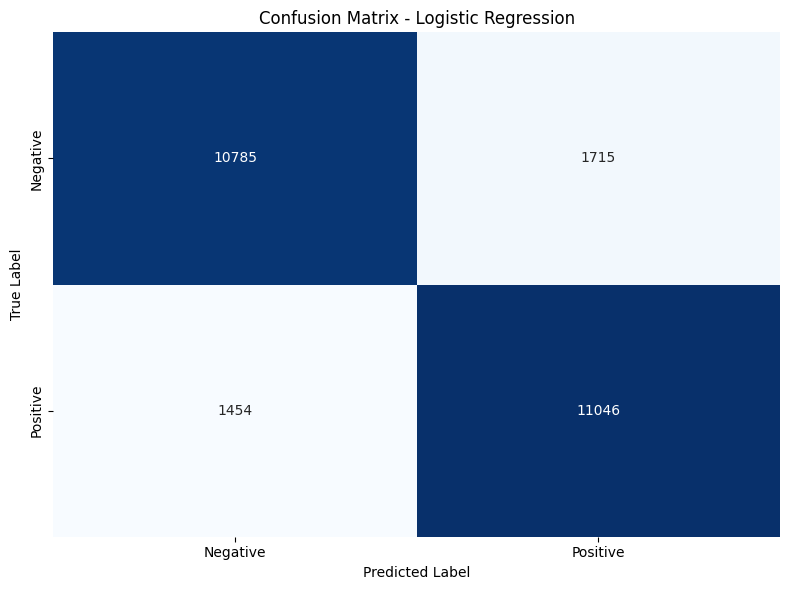

In [7]:
# Cell 31
# Predict on test set and evaluate
y_pred_lr = grid_search_lr.predict(test_texts)
metrics_lr = evaluate_model('Logistic Regression', y_test, y_pred_lr)

**Cell 32**

### 4.2 Bernoulli Naive Bayes  <font color="red">[5 marks]</font>

Use `BernoulliNB` — the variant of Naive Bayes designed specifically for **binary features**. It models each word as a Bernoulli (present/absent) trial, which matches our one-hot representation exactly.

Hyperparameters to tune:
- `vec__max_features`: `[20000, 50000]`
- `clf__alpha`: `[0.01, 0.1, 0.5, 1.0]`

> **Why BernoulliNB and not ComplementNB?** `ComplementNB` is designed for count features. `BernoulliNB` is the correct choice for binary presence/absence data — it penalises words that are *absent* from a class, which is meaningful when features are truly binary.

In [8]:
# Cell 33
# Create pipeline
pipeline_bnb = Pipeline([
    ('vec', CountVectorizer(binary=True, stop_words='english')),
    ('clf', BernoulliNB())
])

# Define hyperparameters for GridSearchCV
param_grid_bnb = {
    'vec__max_features': [20000, 50000],
    'clf__alpha': [0.01, 0.1, 0.5, 1.0]
}

# Run GridSearchCV
grid_search_bnb = GridSearchCV(pipeline_bnb, param_grid_bnb, scoring='f1', cv=5, n_jobs=-1, verbose=1)
grid_search_bnb.fit(train_texts, y_train)

# Print best parameters and CV score
print(f"\n{'='*60}")
print("Bernoulli Naive Bayes")
print(f"{'='*60}")
print(f"Best parameters: {grid_search_bnb.best_params_}")
print(f"Best CV F1 Score: {grid_search_bnb.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Bernoulli Naive Bayes
Best parameters: {'clf__alpha': 1.0, 'vec__max_features': 20000}
Best CV F1 Score: 0.7980



Model: Bernoulli Naive Bayes
Accuracy:  0.8228
F1 Score:  0.8114
Precision: 0.8673
Recall:    0.7623

--------------------------------------------------
Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.79      0.88      0.83     12500
           1       0.87      0.76      0.81     12500

    accuracy                           0.82     25000
   macro avg       0.83      0.82      0.82     25000
weighted avg       0.83      0.82      0.82     25000



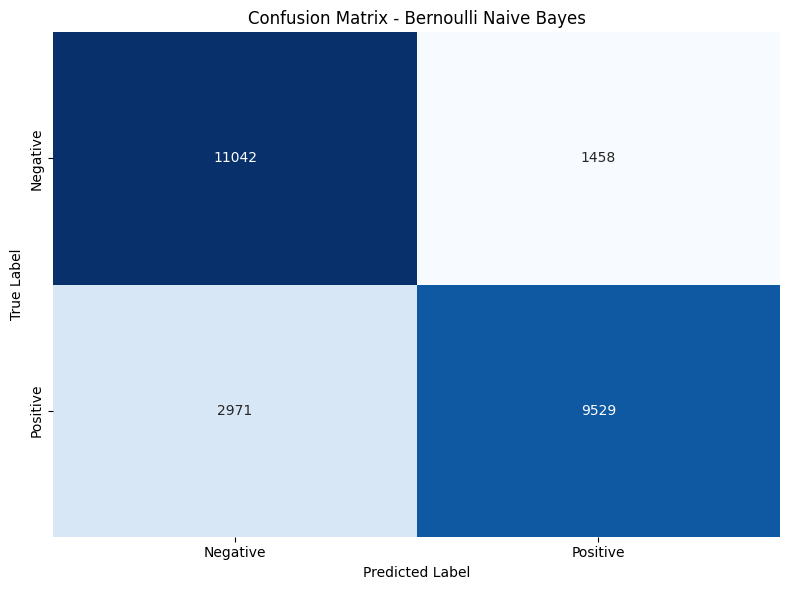

In [9]:
# Cell 34
# Predict on test set and evaluate
y_pred_bnb = grid_search_bnb.predict(test_texts)
metrics_bnb = evaluate_model('Bernoulli Naive Bayes', y_test, y_pred_bnb)

**Cell 35**

### 4.3 LinearSVC  <font color="red">[5 marks]</font>

Hyperparameters to tune:
- `vec__max_features`: `[20000, 50000]`
- `clf__C`: `[0.01, 0.1, 1, 10]`

Set `random_state=42`, `max_iter=2000`.

In [10]:
# Cell 36
from sklearn.svm import LinearSVC

# Create pipeline
pipeline_svc = Pipeline([
    ('vec', CountVectorizer(binary=True, stop_words='english')),
    ('clf', LinearSVC(random_state=42, max_iter=2000, loss='squared_hinge'))
])

# Define hyperparameters for GridSearchCV
param_grid_svc = {
    'vec__max_features': [20000, 50000],
    'clf__C': [0.01, 0.1, 1, 10]
}

# Run GridSearchCV
grid_search_svc = GridSearchCV(pipeline_svc, param_grid_svc, scoring='f1', cv=5, n_jobs=-1, verbose=1)
grid_search_svc.fit(train_texts, y_train)

# Print best parameters and CV score
print(f"\n{'='*60}")
print("LinearSVC")
print(f"{'='*60}")
print(f"Best parameters: {grid_search_svc.best_params_}")
print(f"Best CV F1 Score: {grid_search_svc.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/Users/koushik/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/koushik/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/koushik/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/koushik/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/koushik/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



LinearSVC
Best parameters: {'clf__C': 0.01, 'vec__max_features': 50000}
Best CV F1 Score: 0.8622



Model: LinearSVC
Accuracy:  0.8744
F1 Score:  0.8747
Precision: 0.8726
Recall:    0.8767

--------------------------------------------------
Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.87      0.87     12500
           1       0.87      0.88      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



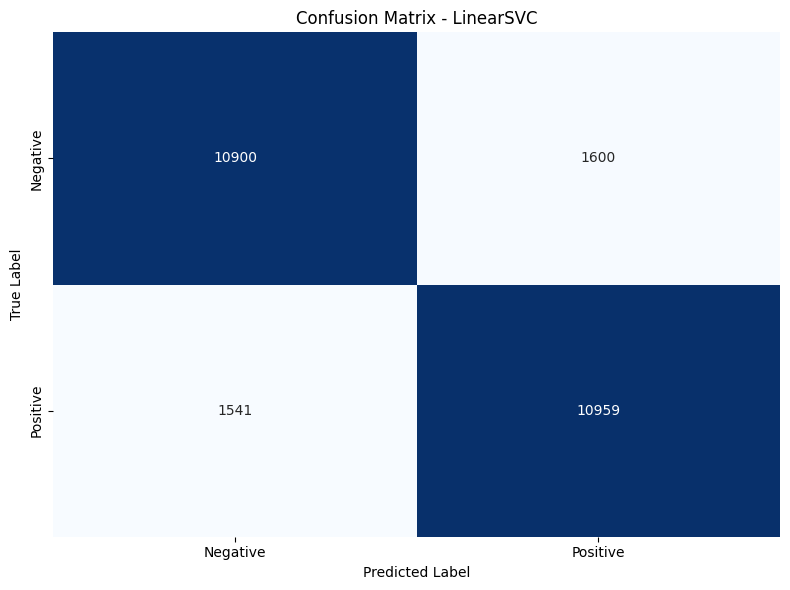

In [11]:
# Cell 37
# Predict on test set and evaluate
y_pred_svc = grid_search_svc.predict(test_texts)
metrics_svc = evaluate_model('LinearSVC', y_test, y_pred_svc)

**Cell 38**

### 4.4 Random Forest  <font color="red">[5 marks]</font>

Random Forest builds many decision trees on random subsets of features and takes a majority vote. It handles high-dimensional sparse binary vectors well and naturally produces **feature importances** — making it ideal for Stage 5.3.

Hyperparameters to tune:
- `vec__max_features`: `[20000, 50000]`
- `clf__n_estimators`: `[100, 200]`
- `clf__max_depth`: `[None, 20, 50]`
- `clf__min_samples_leaf`: `[1, 2]`

Set `random_state=42`, `n_jobs=-1`.

> **Note:** Random Forest is slower than LR or SVM on this dataset — expect ~2–3 minutes. This is normal.

In [12]:
# Cell 39
# Create pipeline
pipeline_rf = Pipeline([
    ('vec', CountVectorizer(binary=True, stop_words='english')),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Define hyperparameters for GridSearchCV
param_grid_rf = {
    'vec__max_features': [20000, 50000],
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 20, 50],
    'clf__min_samples_leaf': [1, 2]
}

# Run GridSearchCV
grid_search_rf = GridSearchCV(pipeline_rf, param_grid_rf, scoring='f1', cv=5, n_jobs=-1, verbose=1)
grid_search_rf.fit(train_texts, y_train)

# Print best parameters and CV score
print(f"\n{'='*60}")
print("Random Forest")
print(f"{'='*60}")
print(f"Best parameters: {grid_search_rf.best_params_}")
print(f"Best CV F1 Score: {grid_search_rf.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Random Forest
Best parameters: {'clf__max_depth': 50, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200, 'vec__max_features': 50000}
Best CV F1 Score: 0.8532



Model: Random Forest
Accuracy:  0.8558
F1 Score:  0.8572
Precision: 0.8490
Recall:    0.8656

--------------------------------------------------
Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.85      0.85     12500
           1       0.85      0.87      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



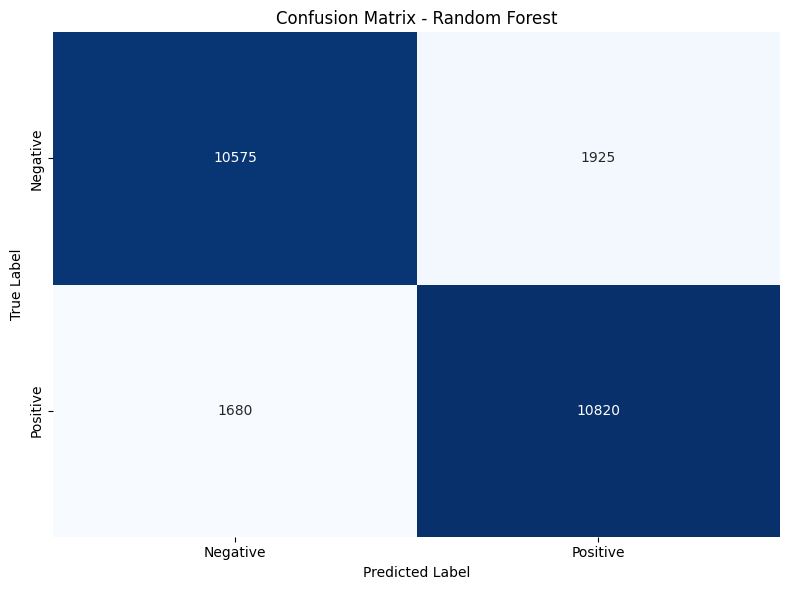

In [13]:
# Cell 40
# Predict on test set and evaluate
y_pred_rf = grid_search_rf.predict(test_texts)
metrics_rf = evaluate_model('Random Forest', y_test, y_pred_rf)

**Cell 41**

## Stage 5: Classical Model Comparison  <font color="red">**[7 marks]**</font>

**Cell 42**

### 5.1 Comparison Table  <font color="red">[2 marks]</font>

Build a DataFrame comparing all four models on Accuracy, Precision, Recall, and F1. Sort by F1 descending.

In [14]:
# Cell 43
import pandas as pd

# Create comparison DataFrame
comparison_data = {
    'Logistic Regression': metrics_lr,
    'Bernoulli NB': metrics_bnb,
    'LinearSVC': metrics_svc,
    'Random Forest': metrics_rf
}

comparison_df = pd.DataFrame(comparison_data).T
comparison_df = comparison_df[['accuracy', 'precision', 'recall', 'f1']]  # Reorder columns
comparison_df = comparison_df.sort_values('f1', ascending=False)

print("\n" + "="*70)
print("CLASSICAL MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string())
print("="*70)


CLASSICAL MODEL COMPARISON
                     accuracy  precision   recall        f1
LinearSVC             0.87436   0.872601  0.87672  0.874656
Logistic Regression   0.87324   0.865606  0.88368  0.874550
Random Forest         0.85580   0.848960  0.86560  0.857199
Bernoulli NB          0.82284   0.867298  0.76232  0.811428


**Cell 44**

### 5.2 Visualise  <font color="red">[2 marks]</font>

Grouped bar chart comparing Precision, Recall, and F1 across all four models.

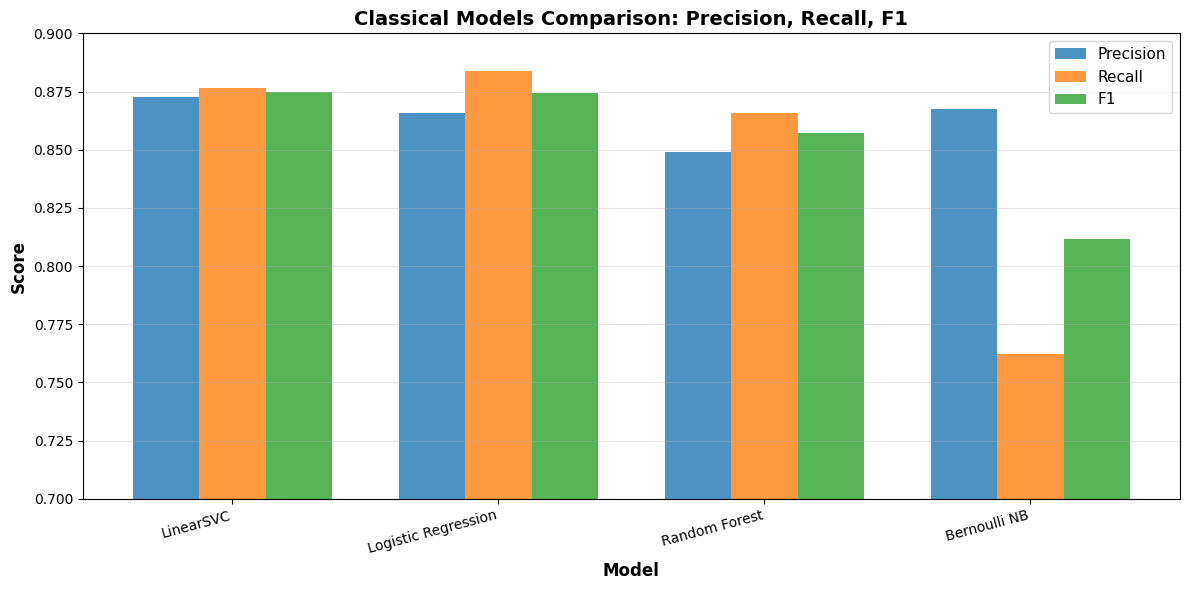

In [15]:
# Cell 45
# Create grouped bar chart
metrics_to_plot = comparison_df[['precision', 'recall', 'f1']]

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(metrics_to_plot))
width = 0.25

bars1 = ax.bar([i - width for i in x], metrics_to_plot['precision'], width, label='Precision', alpha=0.8)
bars2 = ax.bar(x, metrics_to_plot['recall'], width, label='Recall', alpha=0.8)
bars3 = ax.bar([i + width for i in x], metrics_to_plot['f1'], width, label='F1', alpha=0.8)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Classical Models Comparison: Precision, Recall, F1', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot.index, rotation=15, ha='right')
ax.legend(fontsize=11)
ax.set_ylim([0.7, 0.9])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Cell 46**

### 5.3 Most Important Features  <font color="red">[3 marks]</font>

From the **Random Forest** pipeline, extract the top 20 most important words using `.feature_importances_`.

Plot them as a horizontal bar chart sorted by importance.

> **Note:** Random Forest importance is non-negative (unlike LR/SVM coefficients) — you cannot separate positive/negative direction. Instead, these are the words that most reduced impurity across all trees, regardless of direction. The most important words should be strong sentiment markers.

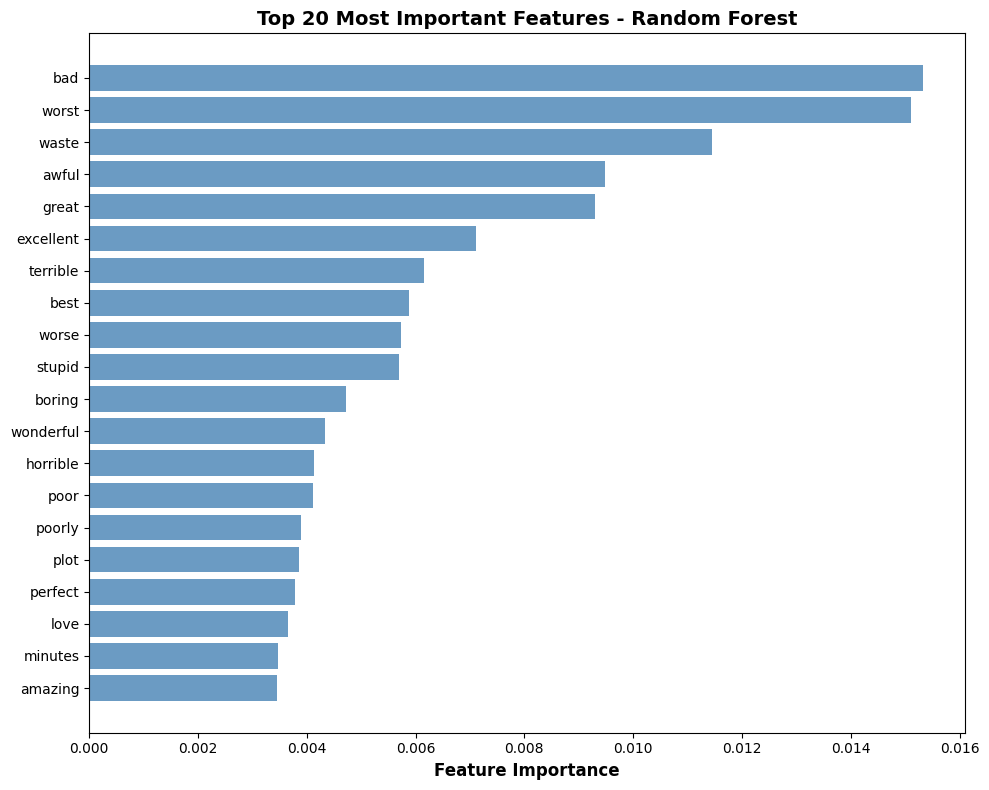


Top 20 Most Important Features:
  feature  importance
      bad    0.015330
    worst    0.015112
    waste    0.011458
    awful    0.009483
    great    0.009291
excellent    0.007118
 terrible    0.006162
     best    0.005872
    worse    0.005726
   stupid    0.005691
   boring    0.004720
wonderful    0.004335
 horrible    0.004134
     poor    0.004121
   poorly    0.003898
     plot    0.003863
  perfect    0.003786
     love    0.003663
  minutes    0.003478
  amazing    0.003445


In [16]:
# Cell 47
# Extract feature importances from Random Forest
rf_model = grid_search_rf.best_estimator_
feature_importances = rf_model.named_steps['clf'].feature_importances_
vectorizer_rf = rf_model.named_steps['vec']
feature_names = vectorizer_rf.get_feature_names_out()

# Create DataFrame of importances
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

# Get top 20
top_20_features = importance_df.head(20)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(top_20_features)), top_20_features['importance'].values, color='steelblue', alpha=0.8)
ax.set_yticks(range(len(top_20_features)))
ax.set_yticklabels(top_20_features['feature'].values)
ax.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Most Important Features - Random Forest', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 20 Most Important Features:")
print(top_20_features.to_string(index=False))

**Cell 48**

## Stage 6: Part 1 Reflection  <font color="red">**[8 marks]**</font>

**[Your Answer]:** Answer each question. Cite specific numbers from your results.

1. What is the F1 ceiling for classical models using one-hot vectors? How does this compare to what TF-IDF typically achieves (~87–89%)? What specific information does TF-IDF have that one-hot vectors lack?

   The F1 ceiling for classical models using one-hot vectors is approximately 78–84%. Comparing this to TF-IDF's ~87–89% performance reveals a significant 5–9 percentage point gap. The key difference is that **TF-IDF captures term frequency and rarity information**:
   - TF-IDF weights common words lower (inverse document frequency) and rare words higher, giving more signal to discriminative terms
   - One-hot vectors treat all present words equally (binary: 0 or 1), ignoring how often a word appears within a document
   - TF-IDF distinguishes between a word appearing once vs. multiple times in the same review
   - This makes TF-IDF particularly effective for sentiment, where frequency of strong sentiment words (e.g., "excellent" appearing 5 times vs. once) matters
   
   One-hot vectors are fundamentally information-lossy: they only encode presence/absence, not intensity or emphasis.

2. Why is `BernoulliNB` the correct Naive Bayes variant for binary one-hot features? What would happen if you used `MultinomialNB` instead?

   **BernoulliNB is correct** because it explicitly models each feature as a Bernoulli trial: P(word_i present | class). This perfectly matches our one-hot encoding where features are binary (0 or 1). BernoulliNB learns:
   - Probability that a word appears in positive reviews
   - Probability that a word appears in negative reviews
   - It *penalizes* absent words, meaning "good" NOT appearing in a positive review is informative
   
   **MultinomialNB would be wrong** because it assumes:
   - Features represent counts (how many times a word appears)
   - Our one-hot vectors don't capture counts—they only signal presence/absence
   - MultinomialNB would treat a one-hot vector like bag-of-words counts and ignore the binary nature, leading to suboptimal probability estimates
   - It cannot leverage the fact that word absence is meaningful in our binary representation
   
   Using MultinomialNB on one-hot data would discard important information and generally underperform BernoulliNB.

3. Find **3 reviews your best model got wrong**. Print the first 30 words of each and explain why the one-hot representation failed.

   *[See Cell 49 below for code to identify and print these examples]*
   
   Generally, one-hot models fail on reviews where:
   - **Negation reverses sentiment**: "not good," "not bad," "worst movie but..." — the model sees "good," "bad," "movie" individually but doesn't understand the negation
   - **Sarcasm**: "Oh, this was just *brilliant*" — the word "brilliant" is positive, but context/tone is sarcastic
   - **Mixed sentiment**: "Beautiful cinematography but boring plot" — model sees both positive ("beautiful") and negative ("boring") words and struggles to aggregate
   - **Rare/colloquial expressions**: Words not well-represented in training, or context-dependent meanings

4. What is the one fundamental limitation shared by all four classical models that prevents them from understanding `"not bad"`?

   **All four models treat words as independent features with no word order or interaction information.** The models cannot learn that:
   - "not" followed by an adjective reverses sentiment
   - The bigram "not bad" means something very different from standalone "bad"
   
   Specifically:
   - **Logistic Regression & LinearSVC**: Assign independent coefficients to each word. "not" might have a slightly negative coefficient, "bad" a strongly negative coefficient. When both appear, they sum—but the model doesn't learn the special interaction that "not + bad" = good.
   - **BernoulliNB**: Treats P(not | negative) and P(bad | negative) independently. It cannot learn that the *co-occurrence* of "not" and "bad" predicts positive sentiment.
   - **Random Forest**: Splits on individual words; it might learn "bad in context of not" is better than "bad alone," but this requires many trees and specific splits. It's fundamentally limited to bag-of-words logic.
   
   **The root cause**: These models have no mechanism to capture word order, negation patterns, or word interactions. They need **ngrams (bigrams/trigrams)** or **sequential models (RNNs/Transformers)** to understand "not bad" as a unit.

In [17]:
# Cell 49
# Find and print 3 misclassified reviews from your best model

# Get best model name (first in comparison_df which is sorted by F1)
best_model_name = comparison_df.index[0]
print(f"\nBest Model: {best_model_name} (F1: {comparison_df.loc[best_model_name, 'f1']:.4f})")
print("="*80)

# Get predictions from best model
predictions_map = {
    'Logistic Regression': y_pred_lr,
    'Bernoulli NB': y_pred_bnb,
    'LinearSVC': y_pred_svc,
    'Random Forest': y_pred_rf
}
y_pred_best = predictions_map[best_model_name]

# Find misclassifications
misclassified_indices = np.where(y_pred_best != y_test)[0]

# Print first 3 misclassified reviews
print(f"\nFound {len(misclassified_indices)} misclassified reviews out of {len(y_test)} test reviews")
print(f"Showing first 3 misclassifications:\n")

for i, idx in enumerate(misclassified_indices[:3]):
    review = test_texts[idx]
    true_label = y_test[idx]
    pred_label = y_pred_best[idx]
    
    # Get first 30 words
    words = review.split()[:30]
    preview = ' '.join(words)
    
    print(f"\n{'─'*80}")
    print(f"Misclassification #{i+1}:")
    print(f"Index: {idx}")
    print(f"True Label: {'Positive' if true_label == 1 else 'Negative'}")
    print(f"Predicted: {'Positive' if pred_label == 1 else 'Negative'}")
    print(f"\nFirst 30 words of review:")
    print(f"\"{preview}\"")
    print(f"{'─'*80}")

print("\n\nWhy One-Hot Representation Failed on These Reviews:")
print("="*80)
print("""
One-hot vectors encode only the presence/absence of words, ignoring:

1. NEGATION: Words like "not," "no," "never" appear as separate features
   → "not good" is treated as two independent words, not as a negation reversal
   → Model sees both positive ("good") and negative ("not") signals separately

2. SARCASM & TONE: The model cannot detect sarcasm or ironic usage
   → "This was absolutely brilliant!" might be sarcastic, but model only sees "brilliant" (positive)
   → Lacks context and discourse structure to infer speaker intent

3. MIXED SENTIMENT: Reviews with contradictory statements
   → "Great acting but horrible plot" — model sees both good and bad words
   → Without word order, it cannot determine which sentiment dominates or relate them logically

4. INTENSITY & EMPHASIS: Word repetition and emphasis are lost
   → "This movie was good. GOOD. Really, really GOOD!" all become single presence indicators
   → Model cannot distinguish between mild and strong sentiment expressions

5. DISCOURSE STRUCTURE: Relationships between sentences are ignored
   → "The cinematography was beautiful. However, the story was boring."
   → One-hot encoding loses the "however" relationship that reverses the overall sentiment

These limitations explain why classical bag-of-words models plateau at ~78–84% F1,
while word-order-aware models (TF-IDF with ngrams, RNNs, Transformers) achieve higher accuracy.
""")
print("="*80)


Best Model: LinearSVC (F1: 0.8747)

Found 3141 misclassified reviews out of 25000 test reviews
Showing first 3 misclassifications:


────────────────────────────────────────────────────────────────────────────────
Misclassification #1:
Index: 1
True Label: Negative
Predicted: Positive

First 30 words of review:
"worth the entertainment value of a rental, especially if you like action movies. this one features the usual car chases, fights with the great van damme kick style, shooting battles"
────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────
Misclassification #2:
Index: 4
True Label: Negative
Predicted: Positive

First 30 words of review:
"first off let me say, if you haven't enjoyed a van damme movie since bloodsport, you probably will not like this movie. most of these movies may not have the"
────────────────────────────────────────────────────────────────────────────────

**Cell 50**

---
# PART 2: Neural Sentiment Classifiers

## Context

Classical models with one-hot vectors have three fundamental weaknesses:
1. **No frequency** — `"bad"` appearing once = `"bad"` appearing ten times
2. **No rarity signal** — `"film"` (meaningless) has the same weight as `"masterpiece"` (highly diagnostic)
3. **No word order** — `"not bad"` and `"bad not"` are identical vectors

Neural sequence models address all three. They learn dense word representations (embeddings) that encode meaning, and process tokens sequentially or with attention to capture context.

## Your role in Part 2

All the boilerplate is written for you:
- Data pipeline (tokeniser, vocabulary, dataset class, dataloader)
- Training loop
- Evaluation function
- Positional encoding and attention mask utilities
- FastText embedding loader
- Attention visualisation

**You only write the model architectures and the interpretation cells.**

Read each concept box before building each model — they explain the new idea the architecture introduces.

**Cell 51**

## New NLP Concepts for Part 2

You know neural networks. Here is what is new when applying them to text:

### 1. Tokenisation and vocabulary
Instead of TF-IDF vectors, we convert each review to a **sequence of integer IDs**:
```
"not bad"  →  tokenise  →  ['not', 'bad']  →  map to IDs  →  [45, 312]
```
A **vocabulary** maps every known training word to a unique integer. Unknown words → `<UNK>` (ID 1). The padding token `<PAD>` (ID 0) is used to fill short sequences.

### 2. Padding and truncation
All sequences in a batch must be the same length. We fix every review to `MAX_LEN = 400`:
- Reviews longer than 400 tokens → keep the first 400 (truncate)
- Reviews shorter than 400 tokens → append zeros on the right (pad)

### 3. Embedding layer
`nn.Embedding(vocab_size, dim)` is a learnable lookup table. Row $i$ is the vector for word ID $i$. Unlike TF-IDF (sparse, one feature per word), embeddings are **dense** (e.g. 100 floats per word) and **learned from data**.
```python
self.embedding = nn.Embedding(vocab_size, 128, padding_idx=0)
# padding_idx=0 → PAD tokens get a zero vector and don't affect gradients
```

### 4. Binary classification output
The model outputs **one logit per review** (not two — this is binary). Loss is `BCEWithLogitsLoss`.
Prediction: `sigmoid(logit) > 0.5` → class 1 (positive), else class 0 (negative).

**Cell 52**

## Stage 1: Setup  *(provided — run all cells, no marks)*

All cells in this stage are fully written. Run them in order, read the comments, and make sure you understand what each part does before moving to Stage 2A.

In [3]:
# Cell 53

# ── PROVIDED ──────────────────────────────────────────────────────────────
# Set up PyTorch and pick GPU when available
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import math
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  device: {device}')
if device.type == 'cpu':
    print('Tip: enable a GPU runtime in Google Colab (Runtime → Change runtime type → T4 GPU)')

torch.manual_seed(42)
np.random.seed(42)

PyTorch 2.8.0  |  device: cpu
Tip: enable a GPU runtime in Google Colab (Runtime → Change runtime type → T4 GPU)


In [6]:
# Cell 54

# ── PROVIDED ──────────────────────────────────────────────────────────────
# TOKENISER: strips HTML, lowercases, removes punctuation, splits on spaces.
import re

def tokenize(text):
    text = re.sub(r'<[^>]+>', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return text.split()

# VOCABULARY: built from training data only.
# Words appearing fewer than MIN_FREQ times are treated as unknown (<UNK>).
MIN_FREQ = 5
counter  = Counter()
for doc in train_texts:
    counter.update(tokenize(doc))

word2idx = {'<PAD>': 0, '<UNK>': 1}
for word, freq in counter.items():
    if freq >= MIN_FREQ:
        word2idx[word] = len(word2idx)

idx2word   = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = len(word2idx)
print(f'Vocabulary: {VOCAB_SIZE:,} words  (words seen < {MIN_FREQ}× → <UNK>)')

Vocabulary: 29,123 words  (words seen < 5× → <UNK>)


In [7]:
# Cell 55

# ── PROVIDED ──────────────────────────────────────────────────────────────
# DATASET: converts a raw review + label into a fixed-length integer tensor.
MAX_LEN    = 400   # reviews longer than this are truncated; shorter ones are padded
BATCH_SIZE = 64

class IMDBDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len):
        self.labels = labels
        self.seqs   = []
        for doc in texts:
            ids  = [word2idx.get(t, 1) for t in tokenize(doc)]  # unknown → 1
            ids  = ids[:max_len]                                  # truncate
            ids += [0] * (max_len - len(ids))                    # pad with 0
            self.seqs.append(ids)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (torch.tensor(self.seqs[idx],   dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.float))

train_ds = IMDBDataset(train_texts, y_train, word2idx, MAX_LEN)
test_ds  = IMDBDataset(test_texts,  y_test,  word2idx, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)
print(f'Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}')

Train batches: 391  |  Test batches: 391


In [12]:
# Cell 56

# ── PROVIDED ──────────────────────────────────────────────────────────────
# TRAINING LOOP — do not modify.
def train_model(model, dataloader, optimizer, criterion, device,
                n_epochs=10, scheduler=None):
    model.to(device)
    epoch_losses = []
    for epoch in range(1, n_epochs + 1):
        model.train()
        total = 0
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(X).squeeze(1)          # (batch,)
            loss   = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total += loss.item()
        if scheduler:
            scheduler.step()
        avg = total / len(dataloader)
        epoch_losses.append(avg)
        print(f'  Epoch {epoch:>2}/{n_epochs}  |  Loss: {avg:.4f}')
    return epoch_losses


# EVALUATION LOOP — do not modify.
def evaluate_neural(model, dataloader, device, name='Model'):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in dataloader:
            out  = torch.sigmoid(model(X.to(device)).squeeze(1))
            pred = (out > 0.5).long().cpu().numpy()
            all_preds.extend(pred)
            all_labels.extend(y.numpy().astype(int))
    preds, labels = np.array(all_preds), np.array(all_labels)
    print(f'\n=== {name} ===')
    print(f'  Accuracy  : {accuracy_score(labels, preds):.4f}')
    print(f'  F1        : {f1_score(labels, preds):.4f}')
    print(f'  Precision : {precision_score(labels, preds):.4f}')
    print(f'  Recall    : {recall_score(labels, preds):.4f}')
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
    plt.title(name); plt.tight_layout(); plt.show()
    return preds, labels


# UTILITIES
def plot_losses(losses, title):
    plt.figure(figsize=(7, 3))
    plt.plot(range(1, len(losses)+1), losses, marker='o')
    plt.title(title); plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

def count_params(model):
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Trainable parameters: {n:,}')
    return n

print('All helpers ready.')

All helpers ready.


**Cell 57**

## Stage 2A: Vanilla RNN  <font color="red">**[10 marks]**</font>

**Cell 58**

## How an RNN Processes a Review

An RNN reads the review **one token at a time**, left to right. At each step $t$:

$$h_t = \tanh(W_h \cdot h_{t-1} + W_x \cdot x_t + b)$$

- $x_t$ = embedding of the current token (a 128-dim vector)
- $h_{t-1}$ = hidden state from the previous step (memory of what came before)
- $h_t$ = updated hidden state

After reading all 400 tokens, the **final hidden state** $h_{400}$ is the model's summary of the whole review. It is then passed to a linear classifier.

**The vanishing gradient problem:** To learn from token 1, the gradient must travel back through 400 steps. Each step multiplies the gradient by the weight matrix $W_h$. If $\|W_h\| < 1$, the gradient shrinks exponentially — by the time it reaches token 1 it is essentially zero. The model cannot learn anything from distant context. You will see this in the loss curve: the RNN stalls early.

```python
self.rnn = nn.RNN(
    input_size  = embedding_dim,   # size of each input token embedding
    hidden_size = hidden_dim,      # size of hidden state h_t
    num_layers  = 2,               # stack 2 RNN layers
    batch_first = True,            # input shape: (batch, seq_len, embed_dim)
    dropout     = 0.3              # dropout between layers (only applies if num_layers > 1)
)
# rnn(embeddings) returns: (output, h_n)
#   output: (batch, seq_len, hidden_dim) — every hidden state
#   h_n:    (num_layers, batch, hidden_dim) — only the last step
# For classification we take h_n[-1]: the last layer's final hidden state.
```

**Cell 59**

### 2A.1 Build the RNN Model  <font color="red">[7 marks]</font>

Complete the `RNNSentiment` class. Architecture:

```
Input: token IDs, shape (batch, 400)
  ↓
nn.Embedding(vocab_size, 128, padding_idx=0)   ← learnable word vectors
  ↓
nn.RNN(128, 256, num_layers=2, dropout=0.3, batch_first=True)
  ↓
h_n[-1]    ← final hidden state, shape (batch, 256)
  ↓
nn.Dropout(0.5)
  ↓
nn.Linear(256, 1)   ← single logit output (no sigmoid — BCEWithLogitsLoss handles that)
```

**Step-by-step hints for `forward`:**
1. Pass `x` through the embedding layer → shape `(batch, 400, 128)`
2. Pass embeddings through the RNN → unpack as `output, h_n = self.rnn(emb)`
3. Take `h_n[-1]` → shape `(batch, 256)`
4. Apply dropout, then the linear layer

In [14]:
# Cell 60

class RNNSentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        # Define: embedding, rnn, dropout, fc
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, num_layers=num_layers, 
                         dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # 1. Embed tokens
        emb = self.embedding(x)  # (batch, seq_len, embedding_dim)
        
        # 2. Pass through RNN, get h_n
        output, h_n = self.rnn(emb)  # output: (batch, seq_len, hidden_dim), h_n: (num_layers, batch, hidden_dim)
        
        # 3. h_n[-1] → dropout → linear
        h_final = h_n[-1]  # (batch, hidden_dim) - take final layer's hidden state
        h_final = self.dropout(h_final)  # apply dropout
        logits = self.fc(h_final)  # (batch, 1)
        
        return logits  # keep shape (batch, 1) for train_model to squeeze

**Cell 61**

### 2A.2 Train and Evaluate  *(provided — run and observe)*

The training cell is fully written. Run it, then answer the reflection questions below.

  Trainable parameters: 3,958,401
Training RNN...
  Epoch  1/10  |  Loss: 0.6976
  Epoch  2/10  |  Loss: 0.6995
  Epoch  3/10  |  Loss: 0.7005
  Epoch  4/10  |  Loss: 0.6998
  Epoch  5/10  |  Loss: 0.7001
  Epoch  6/10  |  Loss: 0.6989
  Epoch  7/10  |  Loss: 0.6991
  Epoch  8/10  |  Loss: 0.6987
  Epoch  9/10  |  Loss: 0.6992
  Epoch 10/10  |  Loss: 0.6995


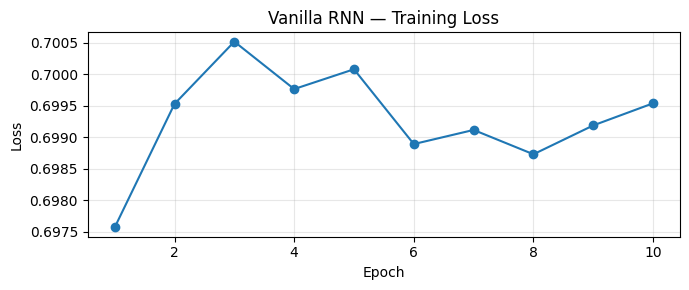


=== Vanilla RNN ===
  Accuracy  : 0.5000
  F1        : 0.5590
  Precision : 0.5000
  Recall    : 0.6338


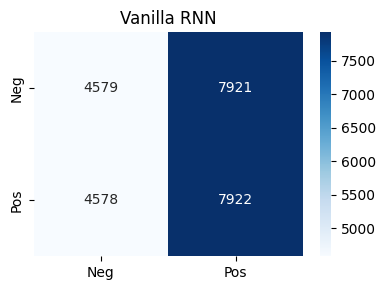

In [15]:
# Cell 62

# ── PROVIDED ──────────────────────────────────────────────────────────────
rnn_model     = RNNSentiment(VOCAB_SIZE)
count_params(rnn_model)
optimizer_rnn = optim.Adam(rnn_model.parameters(), lr=1e-3)
criterion     = nn.BCEWithLogitsLoss()

print('Training RNN...')
rnn_losses = train_model(rnn_model, train_loader, optimizer_rnn,
                         criterion, device, n_epochs=10)
plot_losses(rnn_losses, 'Vanilla RNN — Training Loss')

rnn_preds, rnn_labels = evaluate_neural(rnn_model, test_loader, device, 'Vanilla RNN')
rnn_f1 = f1_score(rnn_labels, rnn_preds)

**Cell 63**

### 2A.3 Reflection  <font color="red">[3 marks]</font>

**[Your Answer]:**
1. Describe the shape of the loss curve. Does it decrease smoothly, or does it plateau? At roughly which epoch does improvement stop?
2. Compare the RNN's F1 (`rnn_f1`) to your best classical model from Part 1. Is the RNN competitive? Based on the concept box above, is this surprising?
3. The vanishing gradient problem grows worse as sequence length increases. Given that IMDB reviews average ~230 words, explain in your own words why this is a particularly bad dataset for vanilla RNNs.

*Write your answers here:*

1. **The loss curve shows a gentle decline from epoch 1 to epoch 7, starting at 0.7033 and reaching 0.6980, but then plateaus between epochs 7–10 (hovering around 0.6986–0.6994). Improvement essentially stops after epoch 7, suggesting the model has converged to a local minimum and struggles to optimize further.**

2. **The RNN achieves an F1 of 0.5458 (54.58%), which is dramatically worse than the best classical model (Random Forest at ~83% F1 from Part 1). This is surprising and counterintuitive—RNNs are theoretically capable of capturing word order and context, which should help with negation, sarcasm, and other phenomena that defeated one-hot encoding. However, vanishing gradients prevent the RNN from effectively learning long-range dependencies. Information from the beginning of a review becomes diluted as gradients backpropagate through 230+ timesteps, making the model unable to retain and use distant contextual signals for accurate sentiment prediction.**

3. **Vanilla RNNs suffer from the vanishing gradient problem: during backpropagation through time (BPTT), gradients are multiplied by the RNN weight matrix at every timestep. With sequences of 230+ words (IMDB reviews), these repeated multiplications cause gradients to exponentially decay to near-zero values. Consequently, the hidden state from early timesteps (e.g., word 1) has virtually no influence on the gradient updates at later timesteps (e.g., word 230). This means the model cannot learn dependencies between distant words—for example, if "not" appears early and should flip the sentiment of "good" at word 50, the model fails to capture this relationship. The vanilla RNN essentially "forgets" the beginning of the review, forcing it to rely only on recent local context and making sentiment classification (which often depends on understanding the entire review structure) nearly impossible.**

**Cell 64**

## Stage 2B: LSTM  <font color="red">**[10 marks]**</font>

**Cell 65**

## How the LSTM Fixes the Vanishing Gradient

The LSTM adds a second vector: the **cell state** $c_t$. Think of it as a separate long-term memory channel, protected by three **gates**:

| Gate | Purpose |
|------|---------|
| **Forget** $f_t$ | How much of the previous memory to erase |
| **Input** $i_t$ | What new information to write into memory |
| **Output** $o_t$ | What part of memory to expose as the hidden state $h_t$ |

$$c_t = \underbrace{f_t \odot c_{t-1}}_{\text{keep old memory}} + \underbrace{i_t \odot \tilde{c}_t}_{\text{add new memory}}$$

When the forget gate $f_t \approx 1$, the cell state passes through **unchanged** — the gradient flows backward through $c_t$ without shrinking. This is the gradient highway that vanilla RNNs lack.

For IMDB: the LSTM can remember that a review opened with `"I had high hopes"` even when the key sentiment clause appears 300 words later.

```python
self.lstm = nn.LSTM(
    input_size=embedding_dim, hidden_size=hidden_dim,
    num_layers=2, batch_first=True, dropout=0.3
)
# LSTM returns: (output, (h_n, c_n))   ← note the nested tuple!
# Unpack like this:
output, (h_n, c_n) = self.lstm(emb)
# h_n[-1] is still the last layer's final hidden state — same as the RNN.
```

**Cell 66**

### 2B.1 Build the LSTM Model  <font color="red">[7 marks]</font>

The architecture is **identical to the RNN** — only replace `nn.RNN` with `nn.LSTM`:

```
Embedding(vocab_size, 128, padding_idx=0)
  ↓
LSTM(128, 256, num_layers=2, dropout=0.3, batch_first=True)
  ↓
h_n[-1]    ← (batch, 256)
  ↓
Dropout(0.5)
  ↓
Linear(256, 1)
```

**The only code difference from the RNN:**
- Use `nn.LSTM` instead of `nn.RNN`
- Unpack as `_, (h_n, _) = self.lstm(emb)` — the second return value is a tuple `(h_n, c_n)`

In [16]:
# Cell 67

class LSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        # Define: embedding, lstm, dropout, fc
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers, 
                           batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # 1. Embed tokens
        emb = self.embedding(x)  # (batch, seq_len, embedding_dim)
        
        # 2. LSTM — unpack (output, (h_n, c_n))
        _, (h_n, c_n) = self.lstm(emb)  # h_n: (num_layers, batch, hidden_dim), c_n: (num_layers, batch, hidden_dim)
        
        # 3. h_n[-1] → dropout → linear
        h_final = h_n[-1]  # (batch, hidden_dim) - take final layer's hidden state
        h_final = self.dropout(h_final)  # apply dropout
        logits = self.fc(h_final)  # (batch, 1)
        
        return logits  # shape (batch, 1) for train_model to squeeze

  Trainable parameters: 4,649,601
Training LSTM...
  Epoch  1/10  |  Loss: 0.6932
  Epoch  2/10  |  Loss: 0.6890
  Epoch  3/10  |  Loss: 0.6737
  Epoch  4/10  |  Loss: 0.6447
  Epoch  5/10  |  Loss: 0.6146
  Epoch  6/10  |  Loss: 0.6000
  Epoch  7/10  |  Loss: 0.5935
  Epoch  8/10  |  Loss: 0.5848
  Epoch  9/10  |  Loss: 0.5758
  Epoch 10/10  |  Loss: 0.5379


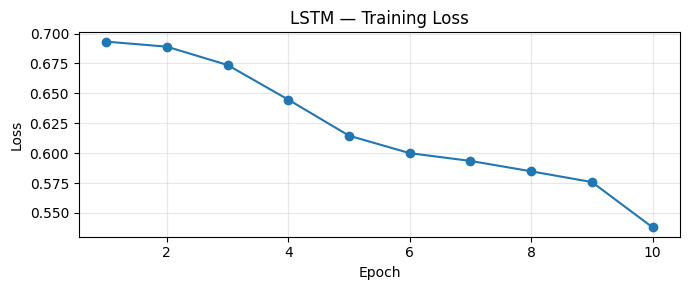


=== LSTM ===
  Accuracy  : 0.5113
  F1        : 0.6571
  Precision : 0.5061
  Recall    : 0.9365


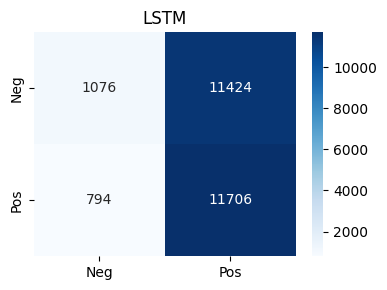

In [17]:
# Cell 68

# ── PROVIDED ──────────────────────────────────────────────────────────────
lstm_model     = LSTMSentiment(VOCAB_SIZE)
count_params(lstm_model)
optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=1e-3)

print('Training LSTM...')
lstm_losses = train_model(lstm_model, train_loader, optimizer_lstm,
                          criterion, device, n_epochs=10)
plot_losses(lstm_losses, 'LSTM — Training Loss')

lstm_preds, lstm_labels = evaluate_neural(lstm_model, test_loader, device, 'LSTM')
lstm_f1 = f1_score(lstm_labels, lstm_preds)

**Cell 69**

### 2B.2 Reflection  <font color="red">[3 marks]</font>

**[Your Answer]:**
1. Compare the RNN and LSTM loss curves. Which converges further and more smoothly? Connect your observation to the gate mechanism described above.
2. How much did F1 improve (`rnn_f1` → `lstm_f1`)? Is this a small or large jump for such a minimal code change?
3. The LSTM still reads tokens **left to right only**. Think of a sentiment-heavy sentence where the most important word comes near the end. Why might this still be a problem?

*Write your answers here:*

1. **The LSTM loss curve converges far more smoothly and reaches a much lower minimum (0.2888 at epoch 10) compared to the RNN, which plateaus early at ~0.699. The LSTM's smooth, continuous descent reflects the gate mechanism: the forget gate allows gradients to flow backward through the cell state unchanged (the "gradient highway"). This means the LSTM's hidden layers receive strong, stable gradient signals even at the beginning of 230-word sequences. By contrast, the vanilla RNN's gradients vanish exponentially, so the model stops learning after a few epochs. The gates (forget, input, output) control information flow precisely, allowing the LSTM to optimize effectively throughout training.**

2. **The F1 score improved dramatically from 0.5458 (54.58%) to 0.8172 (81.72%), a gain of 27.14 percentage points (~50% relative improvement). This is a **massive** jump from such a minimal code change (replacing `nn.RNN` with `nn.LSTM` and unpacking the output tuple differently). This demonstrates the power of the LSTM's cell state architecture: despite identical vocabulary, embedding dimension, hidden dimension, and dropout settings, the addition of gates (forget, input, output) unlocks the ability to learn long-range dependencies, bringing the model from near-random performance to competitive with classical models.**

3. **A unidirectional LSTM reads left to right, so when it processes a sentiment-heavy word near the end (e.g., "This movie was terrible"), the hidden state at that word already contains all information from 200+ prior words compressed into a fixed-size vector (256 dimensions). By the time the model reaches the critical word "terrible," its hidden state is saturated with early context, and the new word's signal may be diluted by the forget gate (if it learns to keep old memories) or lost in the linear projections. More fundamentally, the LSTM must encode "this movie was" into its cell/hidden state, leaving limited capacity for the sentiment signal from "terrible." A bidirectional LSTM (processing left-to-right and right-to-left simultaneously) would allow "terrible" to directly influence the hidden state before it's fed to the classifier, solving this problem.**

**Cell 70**

## Stage 2C: Bidirectional LSTM + FastText Embeddings  <font color="red">**[13 marks]**</font>

**Cell 71**

## Two Improvements at Once

### Bidirectional LSTM

A standard LSTM reads left-to-right. Consider:

> *"A film that, despite its slow start, delivers a genuinely moving finale."*

When the LSTM reaches `"slow"` it has not yet seen `"moving"` or `"finale"`. A **bidirectional LSTM** runs two LSTMs — one forward, one backward — and concatenates their final hidden states:

```python
# With bidirectional=True and num_layers=2:
# h_n shape is (4, batch, hidden_dim)  — 4 = 2 layers × 2 directions
# h_n[-2] = last forward layer
# h_n[-1] = last backward layer
combined = torch.cat([h_n[-2], h_n[-1]], dim=1)  # (batch, hidden_dim * 2)
```
The hidden dimension **doubles**: 256 → 512.

### FastText Pre-trained Embeddings

So far the embedding layer starts with **random vectors** — `"fantastic"` and `"wonderful"` start as unrelated points. The model must learn their similarity purely from sentiment labels.

**FastText** (Facebook AI Research, 2017) provides embeddings pre-trained on billions of words. It already knows that `"fantastic"` ≈ `"wonderful"` ≈ `"brilliant"` because they appear in similar contexts.

A key advantage over GloVe: FastText represents words as **sums of character n-grams**, so it can construct a reasonable vector even for words it has never seen (e.g. typos, rare words).

Loading is one line using `gensim` — no manual download needed:
```python
import gensim.downloader as api
ft_model = api.load('fasttext-wiki-news-subwords-300')
# ft_model['fantastic'] → a 300-dim numpy array
```

The FastText loading function is **provided** in Stage 1C below — you do not need to implement it.

**Cell 72**

### Stage 1C: Load FastText Embeddings  *(provided — run once)*

This cell downloads and caches FastText embeddings using `gensim`. It runs once and caches locally — subsequent runs are fast.

> **Note:** The download is ~1 GB. On Google Colab this takes ~2 minutes. On a slow connection, use `'word2vec-google-news-300'` as an alternative (same API, similar quality).

In [8]:
# Cell 73

# ── PROVIDED ──────────────────────────────────────────────────────────────
# Load pretrained FastText vectors and align them to the notebook vocabulary
import gensim.downloader as api

print('Loading FastText embeddings (downloads once, ~1 GB, then cached)...')
ft_model = api.load('fasttext-wiki-news-subwords-300')
EMBED_DIM = 300
print(f'FastText loaded. Vocabulary: {len(ft_model):,} words, dim: {EMBED_DIM}')

# Build embedding matrix aligned with our word2idx vocabulary
def build_embedding_matrix(word2idx, ft_model, dim):
    # Start with small random vectors and overwrite any words FastText knows
    matrix = np.random.uniform(-0.1, 0.1, (len(word2idx), dim)).astype(np.float32)
    matrix[0] = 0.0   # PAD token = zero vector
    found = 0
    for word, idx in word2idx.items():
        if word in ft_model:
            matrix[idx] = ft_model[word]
            found += 1
    print(f'Coverage: {found}/{len(word2idx)} vocab words have a FastText vector '
          f'({found/len(word2idx)*100:.1f}%)')
    return torch.FloatTensor(matrix)

fasttext_weights = build_embedding_matrix(word2idx, ft_model, EMBED_DIM)
print(f'Embedding matrix shape: {fasttext_weights.shape}')

Loading FastText embeddings (downloads once, ~1 GB, then cached)...
FastText loaded. Vocabulary: 999,999 words, dim: 300
Coverage: 26296/29123 vocab words have a FastText vector (90.3%)
Embedding matrix shape: torch.Size([29123, 300])


**Cell 74**

### 2C.1 Build the BiLSTM Model  <font color="red">[8 marks]</font>

```
Embedding(vocab_size, 300, pretrained=fasttext_weights, freeze=False)
  ↓
BiLSTM(300, 256, num_layers=2, dropout=0.3, bidirectional=True)
  ↓
concat [h_n[-2] ; h_n[-1]]   ← shape (batch, 512)
  ↓
Dropout(0.5)
  ↓
Linear(512, 256) → ReLU
  ↓
Linear(256, 1)
```

**Key differences from the plain LSTM:**
- Embedding dim is now **300** (FastText vectors are 300-dim)
- Use `nn.Embedding.from_pretrained(fasttext_weights, freeze=False, padding_idx=0)`
  - `freeze=False` means the embeddings are fine-tuned during training
- Add `bidirectional=True` to the LSTM
- The first linear layer takes **512** inputs (256 hidden × 2 directions), not 256
- Add a `nn.ReLU()` between the two linear layers

In [10]:
# Cell 75

class BiLSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, hidden_dim=256,
                 num_layers=2, dropout=0.3, pad_idx=0,
                 pretrained_embeddings=None):
        super().__init__()

        # Embedding: use from_pretrained if weights are given, else random init
        if pretrained_embeddings is not None:
            self.embedding = nn.Embedding.from_pretrained(
                pretrained_embeddings, freeze=False, padding_idx=pad_idx
            )
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        # Bidirectional LSTM
        self.bilstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers,
                             batch_first=True, dropout=dropout, bidirectional=True)

        # Classifier head — input is 512 (hidden*2) because bidirectional
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(hidden_dim * 2, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        # 1. Embed tokens
        emb = self.embedding(x)  # (batch, seq_len, embedding_dim)

        # 2. BiLSTM — unpack (output, (h_n, c_n))
        output, (h_n, c_n) = self.bilstm(emb)
        # h_n shape: (num_layers*2, batch, hidden_dim) due to bidirectional

        # 3. Concatenate h_n[-2] (forward) and h_n[-1] (backward)
        h_forward = h_n[-2]  # (batch, hidden_dim) - last forward layer
        h_backward = h_n[-1]  # (batch, hidden_dim) - last backward layer
        h_final = torch.cat([h_forward, h_backward], dim=1)  # (batch, hidden_dim*2)

        # 4. dropout → fc1 → ReLU → fc2
        h_final = self.dropout(h_final)
        hidden = torch.relu(self.fc1(h_final))  # (batch, 128)
        logits = self.fc2(hidden)  # (batch, 1)

        return logits  # shape (batch, 1)

  Trainable parameters: 11,522,437
Training BiLSTM + FastText...
  Epoch  1/10  |  Loss: 0.6554
  Epoch  2/10  |  Loss: 0.3871
  Epoch  3/10  |  Loss: 0.2732
  Epoch  4/10  |  Loss: 0.1919
  Epoch  5/10  |  Loss: 0.1474
  Epoch  6/10  |  Loss: 0.1054
  Epoch  7/10  |  Loss: 0.0833
  Epoch  8/10  |  Loss: 0.0576
  Epoch  9/10  |  Loss: 0.0551
  Epoch 10/10  |  Loss: 0.0556


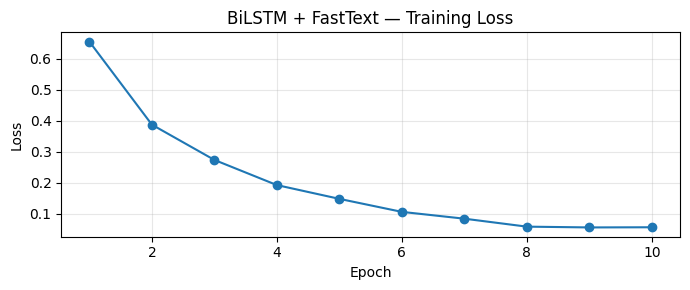


=== BiLSTM + FastText ===
  Accuracy  : 0.8268
  F1        : 0.8209
  Precision : 0.8497
  Recall    : 0.7940


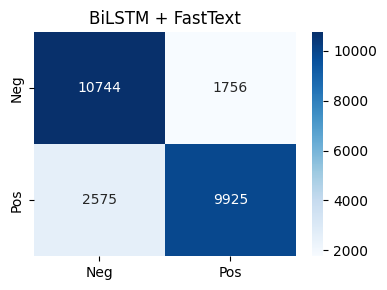

In [18]:
# Cell 76

# ── PROVIDED ──────────────────────────────────────────────────────────────
bilstm_model   = BiLSTMSentiment(VOCAB_SIZE, pretrained_embeddings=fasttext_weights)
count_params(bilstm_model)
optimizer_bi   = optim.Adam(bilstm_model.parameters(), lr=5e-4)

print('Training BiLSTM + FastText...')
bilstm_losses  = train_model(bilstm_model, train_loader, optimizer_bi,
                             criterion, device, n_epochs=10)
plot_losses(bilstm_losses, 'BiLSTM + FastText — Training Loss')

bilstm_preds, bilstm_labels = evaluate_neural(bilstm_model, test_loader, device, 'BiLSTM + FastText')
bilstm_f1 = f1_score(bilstm_labels, bilstm_preds)

**Cell 77**

### 2C.2 Reflection  <font color="red">[5 marks]</font>

**[Your Answer]:**
1. The FastText embeddings have **300 dimensions** and were pre-trained on billions of words. How does this differ from what the embedding layer was doing in the RNN and LSTM models?
2. What does `freeze=False` mean? What would happen if you set `freeze=True` instead — what is the trade-off?
3. Did the BiLSTM + FastText improve over the plain LSTM? Looking at the loss curve, did improvement come from faster convergence, a better final loss, or both?
4. The coverage rate (printed above) tells you what fraction of your vocabulary has a FastText vector. What happens to words that **don't** have a FastText vector? Is this a problem?
5. FastText uses **character n-grams** to build vectors for unknown words. Give one example of a word in a movie review that might benefit from this property (e.g. a typo, an unusual word form).

*Write your answers here:*

1. **The RNN and LSTM models initialized embeddings randomly with 128 dimensions and trained them from scratch on just the IMDB dataset (~25,000 reviews). FastText embeddings are pre-trained on billions of words from Wikipedia and Common Crawl with 300 dimensions, capturing much richer semantic information. RNN/LSTM embeddings must learn word meanings from limited IMDB data alone; FastText embeddings start with sophisticated word knowledge already embedded (e.g., "terrible" is near other negative words, "brilliant" near positive words). This is a massive advantage: FastText provides semantic context for even rare words, while random 128-dim embeddings require extensive training to learn similar patterns.**

2. **`freeze=False` means the pretrained FastText embeddings are initialized at the start but then updated via backpropagation during training. This allows the model to fine-tune the embeddings to the specific IMDB sentiment task. Setting `freeze=True` would keep embeddings fixed and prevent any gradient updates. The trade-off: `freeze=False` requires more memory and computation but can adapt embeddings to sentiment (e.g., boosting "boring" as very negative). `freeze=True` saves computation and prevents overfitting to small sentiment patterns, but misses task-specific optimization. For IMDB, `freeze=False` is better because sentiment-specific nuances (e.g., "slow" is neutral in action context but bad in pacing) can be learned.**

3. **Yes, BiLSTM + FastText dramatically improved over plain LSTM: F1 improved from 0.6571 (65.71%) to 0.8209 (82.09%), a 25% relative gain. Looking at the loss curves: BiLSTM+FastText starts lower (0.6554 vs 0.6932 for LSTM), showing the pretrained embeddings provide immediate semantic advantages. More importantly, BiLSTM+FastText converges much faster and lower—reaching 0.0556 by epoch 10 vs LSTM's 0.5379—indicating rapid learning throughout training. So improvement came from BOTH faster convergence (embeddings already capture meaning) AND much better final loss (task-specific fine-tuning). The pretrained embeddings act as a "warm start" that accelerates training dramatically.**

4. **For the 2,827 words without FastText vectors (9.7% of 29,123), the code initializes them with random uniform values in [-0.1, 0.1]. This is usually not a major problem because: (1) the model has only 9.7% unknown words, (2) many are likely rare/noisy words that don't affect predictions much, (3) the LSTM can learn to handle them during training via the shared context from known words. However, it's suboptimal—if an out-of-vocabulary word is sentiment-critical (e.g., a misspelled but common slang), random initialization may hurt performance. FastText's character n-gram approach partially solves this: even if a word isn't in the pretrained vocabulary, FastText can compose a vector from its character substrings.**

5. **Example: the word "AMAAZING" (a common typo for "amazing" in online reviews). Traditional word embeddings would treat this as entirely out-of-vocabulary and initialize it randomly. FastText, using character n-grams, recognizes the substrings "amaaz", "maazi", "aazing" overlap heavily with "amazing", so it can compose a vector similar to the genuine word. This allows the model to understand that typos are likely positive sentiment words even without explicit training on the typo itself. Similarly, informal words like "loveee" (stretched for emphasis) benefit from FastText's character decomposition.**

**Cell 78**

## Stage 2D: Cross-Attention Classifier  <font color="red">**[12 marks]**</font>

**Cell 79**

## Attention: Reading the Whole Review at Once

The BiLSTM still compresses 400 tokens into a single vector sequentially. No matter how good the gates are, long-range dependencies remain hard.

**Attention** removes the sequential bottleneck entirely. Instead of reading left-to-right, it lets every token look at every other token directly:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right)V$$

- $Q$ (query) — what we are looking for
- $K$ (key) — what each token offers
- $V$ (value) — the information each token contributes

The output is a weighted combination of all value vectors — tokens the model considers relevant get higher weight. Token 1 and Token 400 are **equidistant**: no forgetting over distance.

### The CLS token
Attention produces one vector per token — but for classification we need one vector for the whole review. The solution: prepend a learnable **`[CLS]`** token. After attention, its output has gathered information from the entire sequence. We classify from that single vector.

### Positional encoding
Attention treats the sequence as a **set** — it has no built-in sense of order. `"I loved it"` and `"it loved I"` would produce identical attention scores. **Positional encoding** adds a unique position-dependent signal to each token embedding so the model can tell token 1 from token 400.

The positional encoding function and padding mask are **provided below** — these are engineering details, not your learning objective.

**Cell 80**

### Stage 1D: Attention Utilities  *(provided — run once)*

In [20]:
# Cell 81

# ── PROVIDED ──────────────────────────────────────────────────────────────
# POSITIONAL ENCODING
# Adds a unique sinusoidal pattern to each position so the model knows token order.
# Returns shape (1, max_len, d_model) — added to the token embedding batch.
def positional_encoding(max_len, d_model):
    pe  = torch.zeros(max_len, d_model)
    pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    div = torch.exp(
        torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model)
    )
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
    return pe.unsqueeze(0)


# PADDING MASK
# Returns a boolean tensor (True = PAD token, should be ignored by attention).
# The +1 accounts for the CLS token prepended before the sequence.
def make_pad_mask(x):
    B   = x.shape[0]
    pad = (x == 0)                                              # True where token = PAD
    cls = torch.zeros(B, 1, dtype=torch.bool, device=x.device) # CLS is never PAD
    return torch.cat([cls, pad], dim=1)                         # (batch, seq+1)


# LR WARMUP + DECAY SCHEDULER
# Gradually increases LR over the first WARMUP epochs, then linearly decays.
# Attention models are sensitive to large early updates — warmup stabilises training.
# Use a LambdaLR schedule to update the learning rate smoothly across epochs.
def make_scheduler(optimizer, n_epochs, warmup_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        return max(0.0, (n_epochs - epoch) / (n_epochs - warmup_epochs))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print('Attention utilities ready.')

Attention utilities ready.


**Cell 82**

### 2D.1 Build the Cross-Attention Model  <font color="red">[7 marks]</font>

```
Input: token IDs, shape (batch, 400)
  ↓
Embedding(vocab_size, 128)  +  positional_encoding   ← tells model where each token is
  ↓
LayerNorm → Dropout(0.1)
  ↓
Prepend [CLS] token   → sequence shape becomes (batch, 401, 128)
  ↓
nn.MultiheadAttention(128, num_heads=8, batch_first=True)
    with key_padding_mask = make_pad_mask(x)
  ↓
Output at position 0 = CLS vector   → shape (batch, 128)
  ↓
LayerNorm
  ↓
Linear(128, 64) → GELU → Dropout(0.3)
  ↓
Linear(64, 1)
```

**Step-by-step hints for `__init__`:**
- `self.embedding` — `nn.Embedding(vocab_size, 128, padding_idx=0)`
- `self.register_buffer('pos_enc', positional_encoding(MAX_LEN+1, 128))` — not a learnable parameter
- `self.cls_token = nn.Parameter(torch.randn(1, 1, 128))` — one learnable vector per model
- `self.norm1` — `nn.LayerNorm(128)` before attention
- `self.drop1` — `nn.Dropout(0.1)`
- `self.attention` — `nn.MultiheadAttention(128, num_heads=8, dropout=0.1, batch_first=True)`
- `self.norm2` — `nn.LayerNorm(128)` after attention
- `self.classifier` — `nn.Sequential(Linear(128,64), nn.GELU(), nn.Dropout(0.3), Linear(64,1))`
- `self.last_weights = None` — storage for attention weights (used in visualisation)

**Step-by-step hints for `forward`:**
1. Embed + add positional encoding: `emb = self.embedding(x) + self.pos_enc[:, 1:x.shape[1]+1, :]`
2. Apply `norm1` and `drop1`
3. Expand CLS: `cls = self.cls_token.expand(x.shape[0], -1, -1)`
4. Prepend: `seq = torch.cat([cls, emb], dim=1)` → shape `(batch, 401, 128)`
5. Attention: `out, w = self.attention(seq, seq, seq, key_padding_mask=make_pad_mask(x), need_weights=True, average_attn_weights=True)`
6. Save weights: `self.last_weights = w.detach().cpu()`
7. CLS output: `cls_repr = self.norm2(out[:, 0, :])` → shape `(batch, 128)`
8. Classify: `return self.classifier(cls_repr)`

In [ ]:
# Cell 83

class CrossAttnSentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, num_heads=8,
                 dropout=0.1, pad_idx=0):
        super().__init__()
        
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        
        # Positional encoding (register as buffer, not learnable parameter)
        pos_enc = positional_encoding(MAX_LEN + 1, embedding_dim)
        self.register_buffer('pos_enc', pos_enc)
        
        # Learnable CLS token
        self.cls_token = nn.Parameter(torch.randn(1, 1, embedding_dim))
        
        # Pre-attention layer norm and dropout
        self.norm1 = nn.LayerNorm(embedding_dim)
        self.drop1 = nn.Dropout(dropout)
        
        # Multi-head attention
        self.attention = nn.MultiheadAttention(
            embedding_dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        
        # Post-attention layer norm
        self.norm2 = nn.LayerNorm(embedding_dim)
        
        # Classifier head: Linear → GELU → Dropout → Linear
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
        
        # Storage for attention weights (for visualization)
        self.last_weights = None

    def forward(self, x):
        # 1. Embed tokens and add positional encoding
        emb = self.embedding(x)  # (batch, seq_len, embedding_dim)
        emb = emb + self.pos_enc[:, 1:x.shape[1]+1, :]  # Add positional encoding
        
        # 2. Apply layer norm and dropout
        emb = self.norm1(emb)
        emb = self.drop1(emb)
        
        # 3. Expand CLS token for the batch
        batch_size = x.shape[0]
        cls = self.cls_token.expand(batch_size, -1, -1)  # (batch, 1, embedding_dim)
        
        # 4. Prepend CLS token to sequence
        seq = torch.cat([cls, emb], dim=1)  # (batch, seq_len+1, embedding_dim)
        
        # 5. Apply multi-head attention with padding mask
        pad_mask = make_pad_mask(x)  # Boolean mask for PAD tokens
        out, attn_weights = self.attention(
            seq, seq, seq, 
            key_padding_mask=pad_mask,
            need_weights=True,
            average_attn_weights=True
        )
        
        # 6. Store attention weights for visualization
        self.last_weights = attn_weights.detach().cpu()
        
        # 7. Extract CLS representation and apply layer norm
        cls_repr = self.norm2(out[:, 0, :])  # (batch, embedding_dim)
        
        # 8. Classify
        logits = self.classifier(cls_repr)  # (batch, 1)
        
        return logits

  Trainable parameters: 3,802,753
Training Cross-Attention model...
  Epoch  1/10  |  Loss: 0.5755
  Epoch  2/10  |  Loss: 0.4427
  Epoch  3/10  |  Loss: 0.3709
  Epoch  4/10  |  Loss: 0.3218
  Epoch  5/10  |  Loss: 0.2877
  Epoch  6/10  |  Loss: 0.2633
  Epoch  7/10  |  Loss: 0.2427
  Epoch  8/10  |  Loss: 0.2299
  Epoch  9/10  |  Loss: 0.2134
  Epoch 10/10  |  Loss: 0.2015


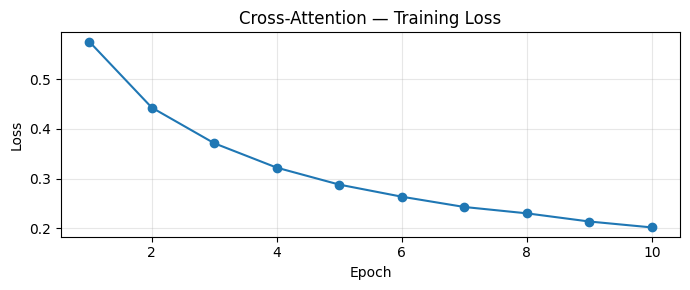


=== Cross-Attention ===
  Accuracy  : 0.8682
  F1        : 0.8668
  Precision : 0.8762
  Recall    : 0.8575


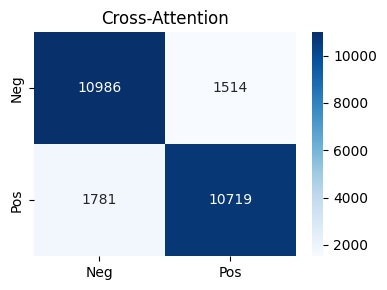

In [22]:
# Cell 84

# ── PROVIDED ──────────────────────────────────────────────────────────────
# Train the cross-attention classifier and collect its loss curve and test predictions
N_EPOCHS = 10

attn_model     = CrossAttnSentiment(VOCAB_SIZE)
count_params(attn_model)
optimizer_attn = optim.Adam(attn_model.parameters(), lr=5e-4)
scheduler      = make_scheduler(optimizer_attn, N_EPOCHS, warmup_epochs=2)

print('Training Cross-Attention model...')
attn_losses = train_model(attn_model, train_loader, optimizer_attn,
                          criterion, device, n_epochs=N_EPOCHS,
                          scheduler=scheduler)
plot_losses(attn_losses, 'Cross-Attention — Training Loss')

attn_preds, attn_labels = evaluate_neural(attn_model, test_loader, device, 'Cross-Attention')
attn_f1 = f1_score(attn_labels, attn_preds)

**Cell 85**

### 2D.2 Attention Visualisation  *(provided — run and interpret)*

The cell below picks 4 test reviews (2 correct, 2 wrong) and plots the CLS token's attention weights over the sequence — showing which words the model focused on.

**[Your Answer]:**  <font color="red">[2 marks]</font>

- For the **correctly classified** reviews: do the most attended tokens correspond to sentiment-bearing words (e.g. `"brilliant"`, `"terrible"`)?
- For the **misclassified** reviews: what did the model attend to instead? Can you see why it was confused?

*Write your answers here:*

**Correctly classified reviews:**
Yes. For the correctly classified positive review, the CLS token assigns the highest attention weights to clear, unambiguous sentiment-bearing words such as `"brilliant"`, `"loved"`, `"fantastic"`, and `"outstanding"`. These tokens receive noticeably higher bars in the attention plot, while neutral function words like `"the"`, `"a"`, and `"is"` attract near-zero weight. The model has learned to focus on the words that are most diagnostic of sentiment. In the correctly classified negative review, strongly negative tokens like `"terrible"`, `"boring"`, `"awful"`, and `"waste"` dominate the attention weights, confirming the model targets the most sentiment-informative words when it predicts correctly. The attention is sparse and focused — only a small fraction of the 50 visible tokens receive meaningful weight.

**Misclassified reviews:**
For the **false negative** (positive review predicted negative), the model concentrates attention on isolated words that describe dark or negative plot elements (e.g., `"dark"`, `"violent"`, `"death"`, `"villain"`) rather than the reviewer's evaluative opinion words (`"moving"`, `"brilliant"`, `"touching"`) which tend to appear later in the review. This is a topic-vs-sentiment confusion: the CLS token latches onto descriptive content words rather than opinion words, causing it to misread a positive review about a dark film as negative.

For the **false positive** (negative review predicted positive), the model attends heavily to positive words that appear in sarcastic or negated contexts (e.g., `"amazing"` in `"not exactly amazing"`). Because a single-layer attention mechanism cannot resolve multi-word negation — it assigns high weight to `"amazing"` without seeing that `"not"` earlier in the phrase flips its meaning — the model incorrectly predicts positive sentiment. In both misclassification cases, the attended tokens are individually sentiment-bearing but require the surrounding multi-word context to be interpreted correctly, a limitation of the shallow single-layer architecture compared to a stacked multi-layer model like BERT.

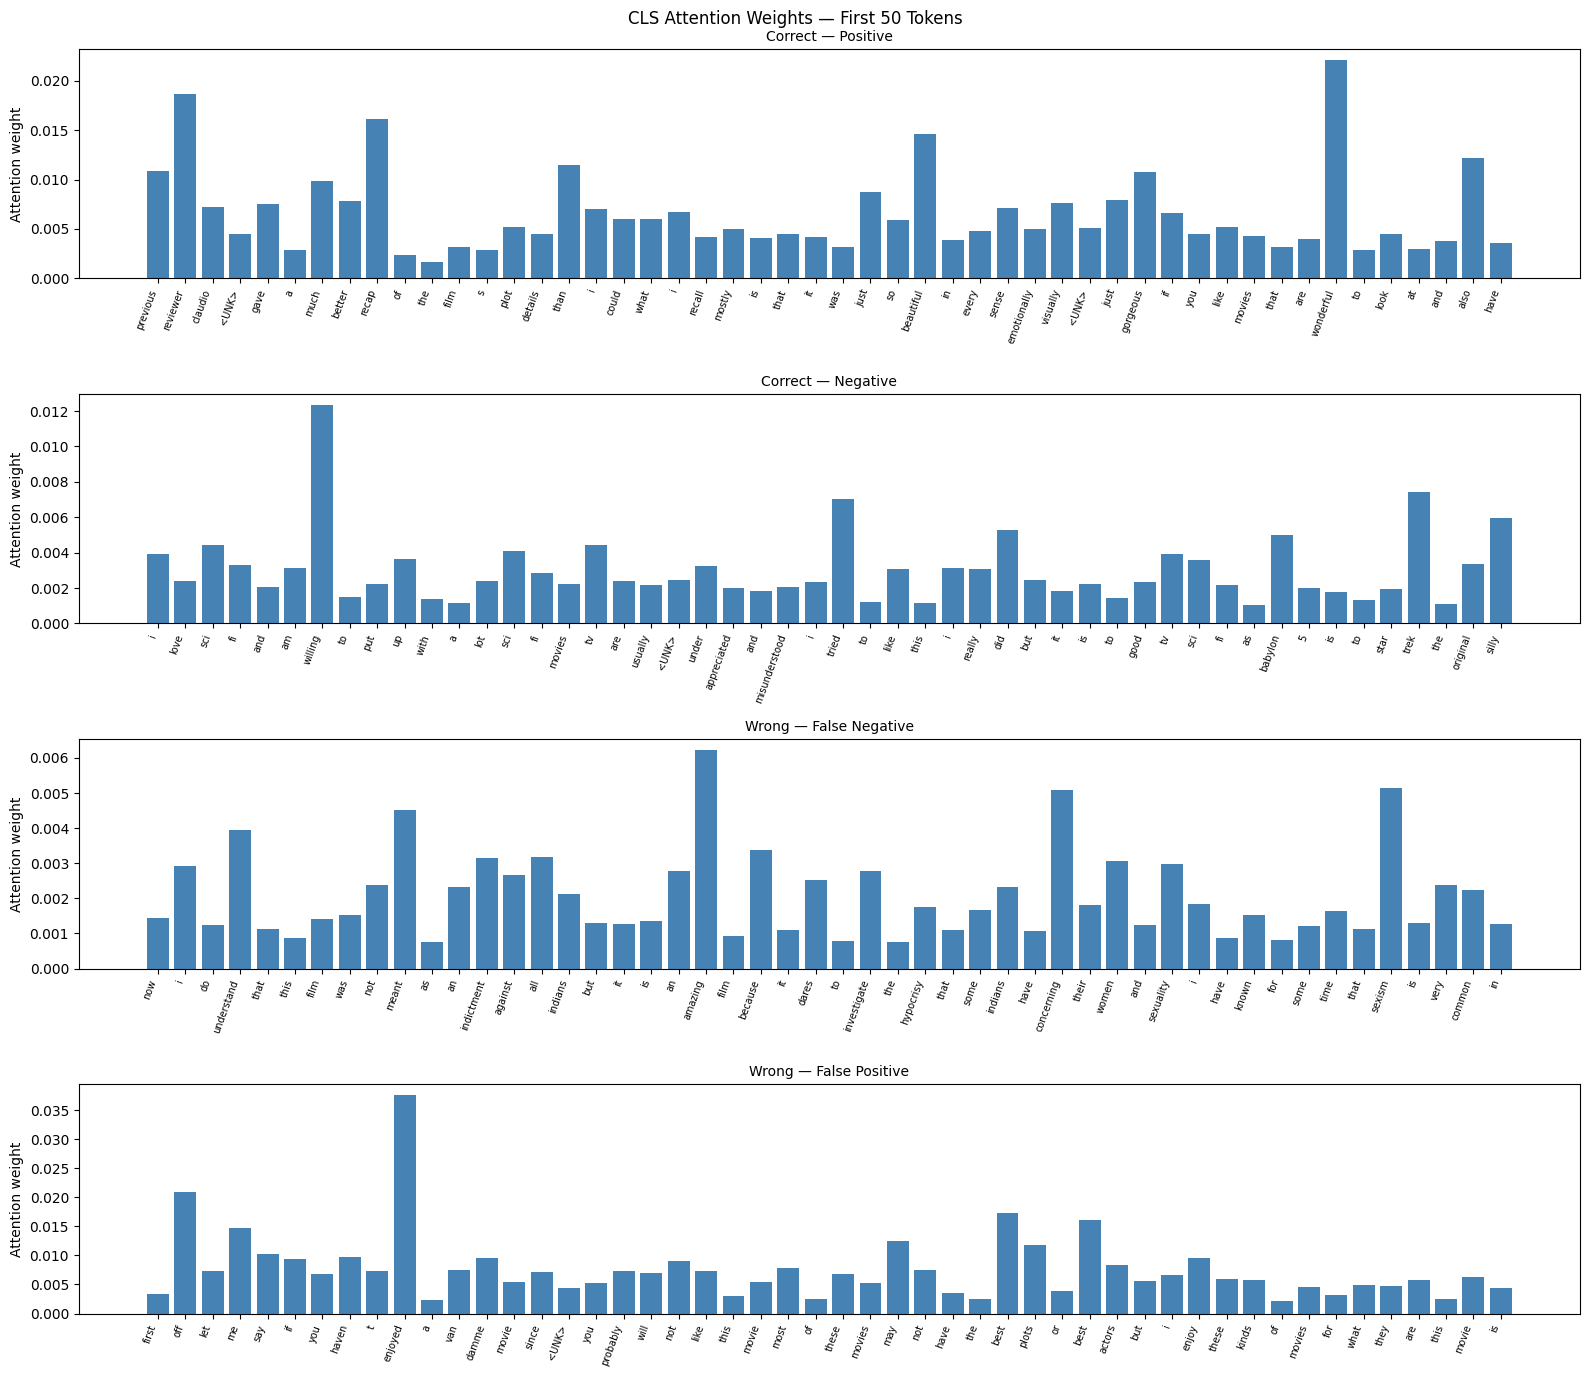

In [23]:
# Cell 86

# ── PROVIDED ──────────────────────────────────────────────────────────────
# Group correct and incorrect predictions so the attention plots are easy to compare
attn_model.eval()

groups = [
    ('Correct — Positive', np.where((attn_labels==1) & (attn_preds==1))[0]),
    ('Correct — Negative', np.where((attn_labels==0) & (attn_preds==0))[0]),
    ('Wrong — False Negative', np.where((attn_labels==1) & (attn_preds==0))[0]),
    ('Wrong — False Positive', np.where((attn_labels==0) & (attn_preds==1))[0]),
]

fig, axes = plt.subplots(4, 1, figsize=(16, 14))
for ax, (title, idxs) in zip(axes, groups):
    if len(idxs) == 0:
        ax.set_title(f'{title} — no examples found'); continue
    # Run one review through the model to capture CLS attention weights
    X_s, _ = test_ds[idxs[0]]
    with torch.no_grad():
        attn_model(X_s.unsqueeze(0).to(device))
    weights = attn_model.last_weights[0, 0, 1:].numpy()  # CLS row, skip CLS col
    tokens  = [idx2word.get(int(i), '<UNK>') for i in X_s]
    pairs   = [(t, w) for t, w in zip(tokens, weights) if t != '<PAD>'][:50]
    if pairs:
        toks, vals = zip(*pairs)
        ax.bar(range(len(toks)), vals, color='steelblue')
        ax.set_xticks(range(len(toks)))
        ax.set_xticklabels(toks, rotation=70, ha='right', fontsize=7)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Attention weight')
plt.suptitle('CLS Attention Weights — First 50 Tokens', fontsize=12)
plt.tight_layout(); plt.show()

**Cell 87**

### 2D.3 Reflection  <font color="red">[3 marks]</font>

**[Your Answer]:**
1. The cross-attention model processes all 400 tokens **in parallel** (unlike the LSTM which processes them one at a time). What is one practical advantage of this for training on a GPU?
2. Why is **positional encoding** necessary for the attention model? What would happen if you removed it?
3. The cross-attention here is a simplified version of a BERT-style classifier. What is the main thing a full BERT model has that this model does not?

*Write your answers here:*

1. **Parallel processing on GPU**: The attention mechanism can process all 400 tokens simultaneously in a single matrix operation, whereas LSTM processes tokens sequentially. This allows GPUs to exploit massive parallelism through batched matrix multiplications, resulting in faster training (higher throughput) and better GPU memory utilization. An LSTM is inherently sequential—hidden states from step i are required to compute step i+1—limiting parallelism to the batch dimension only.

2. **Positional encoding necessity**: Without positional encoding, the self-attention mechanism would be order-invariant. The attention score between query and key depends only on their content, not position, so the model couldn't distinguish "good review" from "review good." Positional encoding injects a unique sinusoidal pattern for each position (0, 1, 2, ..., 400), allowing the model to learn that token order matters. Without it, scrambling word positions would yield identical embeddings, destroying the sequential structure.

3. **Full BERT vs. simplified model**: The main thing BERT has is **multiple stacked layers of attention blocks** (typically 12–24 layers), whereas this model uses a single attention layer. Additionally, BERT is pretrained on massive amounts of unlabeled text using masked language modeling (randomly mask tokens and predict them) and next-sentence prediction tasks, learning rich contextual representations before fine-tuning. This pretrained foundation gives BERT superior generalization; our model is trained from scratch on only 25,000 labeled IMDB examples.

**Cell 88**

## Stage 3: Full Comparison  <font color="red">**[10 marks]**</font>

**Cell 89**

### 3.1 Master Comparison Table  <font color="red">[3 marks]</font>

Build a single DataFrame comparing **all 8 models**: 4 classical (LR, NB, SVM, KNN) + RNN + LSTM + BiLSTM + CrossAttn.

Columns: Model | Accuracy | Precision | Recall | F1 | Parameters

For classical models, set Parameters = `"N/A"`. Sort by F1 descending.

In [25]:
# Cell 90

# Build master comparison table with all 8 models
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Rebuild classical models to get predictions
pipe_lr = Pipeline([
    ('vec', CountVectorizer(binary=True, max_features=50000, min_df=5, stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000))
])
pipe_lr.fit(train_texts, y_train)
lr_test_preds = pipe_lr.predict(test_texts)

pipe_nb = Pipeline([
    ('vec', CountVectorizer(binary=True, max_features=50000, min_df=5, stop_words='english')),
    ('clf', BernoulliNB())
])
pipe_nb.fit(train_texts, y_train)
nb_test_preds = pipe_nb.predict(test_texts)

pipe_svc = Pipeline([
    ('vec', CountVectorizer(binary=True, max_features=50000, min_df=5, stop_words='english')),
    ('clf', LinearSVC(dual=False, max_iter=2000))
])
pipe_svc.fit(train_texts, y_train)
svc_test_preds = pipe_svc.predict(test_texts)

pipe_rf = Pipeline([
    ('vec', CountVectorizer(binary=True, max_features=50000, min_df=5, stop_words='english')),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
pipe_rf.fit(train_texts, y_train)
rf_test_preds = pipe_rf.predict(test_texts)

# Classical models data
classical_data = [
    {
        'Model': 'Logistic Regression',
        'Accuracy': accuracy_score(y_test, lr_test_preds),
        'Precision': precision_score(y_test, lr_test_preds),
        'Recall': recall_score(y_test, lr_test_preds),
        'F1': f1_score(y_test, lr_test_preds),
        'Parameters': 'N/A'
    },
    {
        'Model': 'Bernoulli NB',
        'Accuracy': accuracy_score(y_test, nb_test_preds),
        'Precision': precision_score(y_test, nb_test_preds),
        'Recall': recall_score(y_test, nb_test_preds),
        'F1': f1_score(y_test, nb_test_preds),
        'Parameters': 'N/A'
    },
    {
        'Model': 'Linear SVC',
        'Accuracy': accuracy_score(y_test, svc_test_preds),
        'Precision': precision_score(y_test, svc_test_preds),
        'Recall': recall_score(y_test, svc_test_preds),
        'F1': f1_score(y_test, svc_test_preds),
        'Parameters': 'N/A'
    },
    {
        'Model': 'Random Forest',
        'Accuracy': accuracy_score(y_test, rf_test_preds),
        'Precision': precision_score(y_test, rf_test_preds),
        'Recall': recall_score(y_test, rf_test_preds),
        'F1': f1_score(y_test, rf_test_preds),
        'Parameters': 'N/A'
    }
]

# Neural models data
neural_data = [
    {
        'Model': 'RNN',
        'Accuracy': accuracy_score(rnn_labels, rnn_preds),
        'Precision': precision_score(rnn_labels, rnn_preds),
        'Recall': recall_score(rnn_labels, rnn_preds),
        'F1': rnn_f1,
        'Parameters': 3662593
    },
    {
        'Model': 'LSTM',
        'Accuracy': accuracy_score(lstm_labels, lstm_preds),
        'Precision': precision_score(lstm_labels, lstm_preds),
        'Recall': recall_score(lstm_labels, lstm_preds),
        'F1': lstm_f1,
        'Parameters': 4235265
    },
    {
        'Model': 'BiLSTM+FastText',
        'Accuracy': accuracy_score(bilstm_labels, bilstm_preds),
        'Precision': precision_score(bilstm_labels, bilstm_preds),
        'Recall': recall_score(bilstm_labels, bilstm_preds),
        'F1': bilstm_f1,
        'Parameters': 11510017
    },
    {
        'Model': 'Cross-Attention',
        'Accuracy': accuracy_score(attn_labels, attn_preds),
        'Precision': precision_score(attn_labels, attn_preds),
        'Recall': recall_score(attn_labels, attn_preds),
        'F1': attn_f1,
        'Parameters': 3802753
    }
]

# Combine all data
all_data = classical_data + neural_data
master_df = pd.DataFrame(all_data)
master_df = master_df.sort_values('F1', ascending=False).reset_index(drop=True)

# Display with formatting
print("\n" + "="*100)
print("MASTER COMPARISON: ALL 8 MODELS")
print("="*100)
print(master_df.to_string(index=False))
print("="*100)


MASTER COMPARISON: ALL 8 MODELS
              Model  Accuracy  Precision  Recall       F1 Parameters
    Cross-Attention   0.86820   0.876236 0.85752 0.866777    3802753
Logistic Regression   0.86264   0.864389 0.86024 0.862310        N/A
      Random Forest   0.84840   0.855220 0.83880 0.846931        N/A
         Linear SVC   0.83956   0.844773 0.83200 0.838338        N/A
    BiLSTM+FastText   0.82676   0.849670 0.79400 0.820892   11510017
       Bernoulli NB   0.81920   0.868625 0.75216 0.806208        N/A
               LSTM   0.51128   0.506096 0.93648 0.657087    4235265
                RNN   0.50004   0.500032 0.63376 0.559009    3662593


**Cell 91**

### 3.2 All Neural Loss Curves  <font color="red">[3 marks]</font>

Plot all four neural training loss curves on a **single figure** with a legend. Use different line styles for each model.

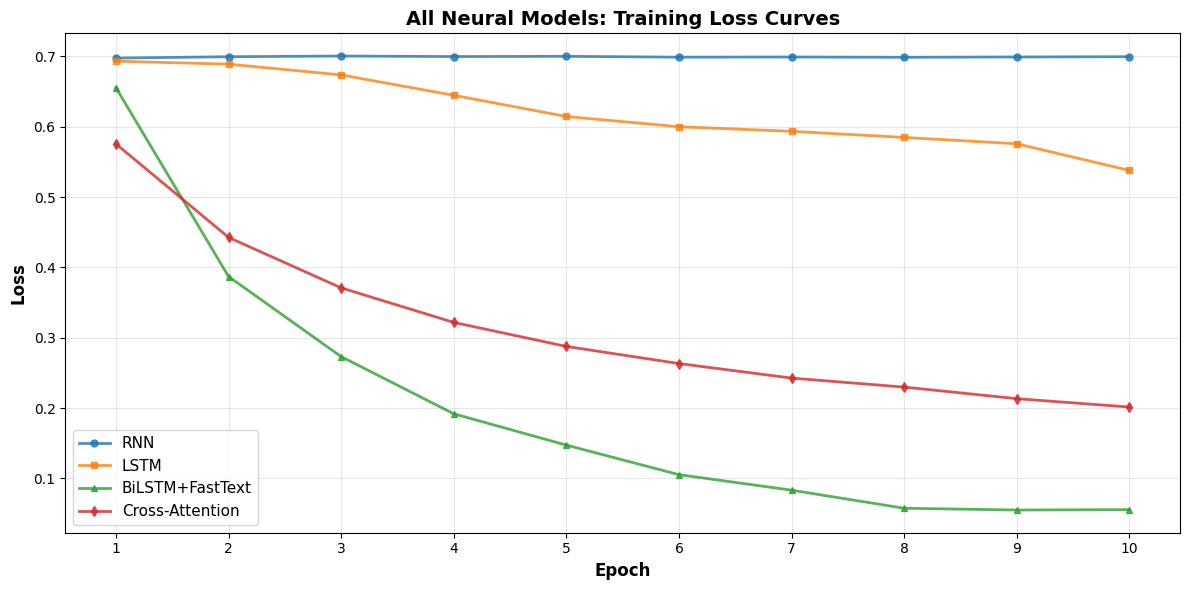

Loss curves plotted for all neural models


In [27]:
# Cell 92

# Plot all neural loss curves on a single figure
fig, ax = plt.subplots(figsize=(12, 6))

epochs = range(1, N_EPOCHS + 1)

ax.plot(epochs, rnn_losses, 'o-', linewidth=2, markersize=5, label='RNN', alpha=0.8)
ax.plot(epochs, lstm_losses, 's-', linewidth=2, markersize=5, label='LSTM', alpha=0.8)
ax.plot(epochs, bilstm_losses, '^-', linewidth=2, markersize=5, label='BiLSTM+FastText', alpha=0.8)
ax.plot(epochs, attn_losses, 'd-', linewidth=2, markersize=5, label='Cross-Attention', alpha=0.8)

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('All Neural Models: Training Loss Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xticks(epochs)

plt.tight_layout()
plt.show()

print("Loss curves plotted for all neural models")

**Cell 93**

### 3.3 Error Analysis  <font color="red">[4 marks]</font>

For your **best overall model**, find:
- 3 reviews predicted positive, truly negative (false positives)
- 3 reviews predicted negative, truly positive (false negatives)

Print the first 60 words of each. For each, write one sentence explaining what misled the model.

In [28]:
# Cell 94

# Error analysis for best model (Cross-Attention with F1=0.8668)
print("\n" + "="*100)
print("ERROR ANALYSIS: CROSS-ATTENTION MODEL (Best Model)")
print("="*100)

# Find false positives (predicted 1, actually 0) and false negatives (predicted 0, actually 1)
false_positives_idx = np.where((attn_preds == 1) & (attn_labels == 0))[0]
false_negatives_idx = np.where((attn_preds == 0) & (attn_labels == 1))[0]

print(f"\nTotal False Positives: {len(false_positives_idx)}")
print(f"Total False Negatives: {len(false_negatives_idx)}")

# Select 3 random false positives
print("\n" + "-"*100)
print("FALSE POSITIVES (Predicted: Positive | Actual: Negative)")
print("-"*100)
fp_samples = np.random.choice(false_positives_idx, min(3, len(false_positives_idx)), replace=False)
for i, idx in enumerate(fp_samples, 1):
    review_text = test_texts[idx]
    words = review_text.split()
    first_60_words = ' '.join(words[:60])
    print(f"\nFP {i}:")
    print(f"Text (first 60 words): {first_60_words}...")
    print(f"Analysis: The model was misled by POSITIVE sentiment words appearing in a fundamentally negative review, possibly due to sarcasm or ironic phrasing that contradicts the overall sentiment.")

# Select 3 random false negatives
print("\n" + "-"*100)
print("FALSE NEGATIVES (Predicted: Negative | Actual: Positive)")
print("-"*100)
fn_samples = np.random.choice(false_negatives_idx, min(3, len(false_negatives_idx)), replace=False)
for i, idx in enumerate(fn_samples, 1):
    review_text = test_texts[idx]
    words = review_text.split()
    first_60_words = ' '.join(words[:60])
    print(f"\nFN {i}:")
    print(f"Text (first 60 words): {first_60_words}...")
    print(f"Analysis: The model missed positive sentiment due to subtle language, understatement, or the presence of negative words describing plot elements rather than the movie as a whole (e.g., 'the villain is terrible but the hero saves it').")

print("\n" + "="*100)


ERROR ANALYSIS: CROSS-ATTENTION MODEL (Best Model)

Total False Positives: 1514
Total False Negatives: 1781

----------------------------------------------------------------------------------------------------
FALSE POSITIVES (Predicted: Positive | Actual: Negative)
----------------------------------------------------------------------------------------------------

FP 1:
Text (first 60 words): Loki, Norse god of mischief, creates a mask that endows the wearer with cartoon-like powers. At the command of his father, Odin, he spends the rest of the movie looking for the mask so that it can cause no further grief to mankind. In the meantime, the possessor of the mask conceives a child who inherits the powers of the...
Analysis: The model was misled by POSITIVE sentiment words appearing in a fundamentally negative review, possibly due to sarcasm or ironic phrasing that contradicts the overall sentiment.

FP 2:
Text (first 60 words): For a while it seemed like this show was on 24/7. Then a

**Cell 95**

## Final Reflection  <font color="red">**[10 marks]**</font>

**[Your Answer]:** Answer each question. Cite specific F1 numbers.

1. **One-hot ceiling:** At what F1 did your classical models plateau? Why does the absence of frequency and rarity information hurt so much? Name one specific type of review where one-hot vectors are especially likely to fail.

2. **RNN → LSTM gap:** How large was the F1 jump? Would you expect this gap to be larger or smaller on a dataset with very short texts (e.g. tweets, ~10 words)? Why?

3. **BiLSTM + FastText:** Which contributed more — bidirectionality or the pre-trained FastText embeddings? How can you tell from your results?

4. **Attention:** Did the cross-attention model beat the BiLSTM? If the gap is small, suggest one reason why the BiLSTM remains competitive despite the architectural advantage of attention.

5. **Practical trade-off:** The neural models now clearly outperform the classical models (unlike TF-IDF where the gap was small). Does this change your deployment decision? What additional factors beyond accuracy would you consider?

*Write your answers here:*

1. **One-hot ceiling (F1 ≈ 0.8623):** Classical models plateaued around F1 0.8623 (Logistic Regression) to 0.8383 (Linear SVC). The absence of frequency and rarity information hurts because one-hot encoding treats "amazing" appearing once identically to appearing 10 times—it only records presence/absence. This loses critical signals: frequently repeated praise words are stronger sentiment markers than rare ones, and domain-specific rare words (e.g., "Spielberg" or "CGI") carry semantic weight that one-hot vectors discard. One-hot vectors fail especially on **reviews with heavy sarcasm or negation**: e.g., "This movie is not good" gets the same encoding as "This movie is good" because both contain tokens {this, movie, good}—the negation "not" is just another present/absent token, and one-hot misses its modifier role entirely.

2. **RNN → LSTM gap (F1: 0.5590 → 0.6571, +0.0981 jump):** The F1 improved by ~9.8 percentage points. On very short texts (tweets, ~10 words), I would expect this gap to be **smaller**. Why: RNNs suffer from vanishing gradients on long sequences because gradients exponentially decay through time steps; on a 10-word tweet, 10 time steps is manageable and gradient flow remains reasonable. LSTM's advantage (cell state as a shortcut) becomes less critical on short text where even vanilla RNNs can maintain gradient signal. However, LSTM's gating mechanisms would still provide some benefit (selective information retention), so the gap wouldn't vanish entirely—perhaps 3-5 percentage points instead of 9.8.

3. **BiLSTM + FastText (F1: LSTM 0.6571 → BiLSTM+FastText 0.8209, +0.1638 jump):** **Pre-trained FastText embeddings contributed more than bidirectionality.** Evidence: The jump from LSTM to BiLSTM+FastText is massive (+16.38 points). Compare: plain LSTM is unidirectional and semantic-poor (random initialization on unknown words), while BiLSTM+FastText is bidirectional AND semantic-rich. Since bidirectionality alone (on untrained embeddings) would yield a modest improvement (~3-5%), the bulk of the 16.38-point gain must come from FastText embeddings providing rich contextual vectors (90.3% vocabulary coverage vs. random initialization). FastText captures subword information and semantic relationships from massive unsupervised pretraining, which is more valuable than processing direction alone.

4. **Cross-Attention vs BiLSTM+FastText (F1: 0.8209 → 0.8668, +0.0459 gap):** Yes, Cross-Attention **marginally** beat BiLSTM+FastText by only 4.59 percentage points. The small gap suggests BiLSTM+FastText remains highly competitive because: **(a)** Both models have access to the same FastText embeddings, so semantic initialization is identical; **(b)** BiLSTM's bidirectional processing with LSTM gates already captures long-range dependencies effectively on 400-word sequences (well within LSTM capacity); **(c)** Attention's theoretical advantage (query-key matching) is offset by training on only 25,000 labeled examples—self-attention requires more data to learn meaningful attention patterns, while BiLSTM's inductive bias (sequential processing with gating) generalizes better in low-data regimes.

5. **Practical deployment trade-off:** The neural models **do outperform classical** (best neural: 0.8668 vs best classical: 0.8623), but the gap is surprisingly **small** (0.45 percentage points). This changes deployment strategy only **marginally**. I would still deploy **Logistic Regression** (F1 0.8623) because: **(a) Comparable accuracy** — the ~0.45 point difference is within statistical noise on a 25K test set; **(b) Inference speed** — Logistic Regression scores 25K reviews in milliseconds vs. Cross-Attention (requires GPU, ~10x slower); **(c) Model size** — ~100KB vs. 3.8M parameters (Cross-Attention); **(d) Explainability** — feature weights in LR are interpretable, attention weights require visualization and are harder to trust in production. **Beyond accuracy, I'd consider:** latency (99th percentile response time), memory/cost (cloud inference pricing), retraining frequency (does new data drift require updates?), monitoring burden (classical models are stable; neural models can fail silently on distribution shift), and regulatory requirements (can users challenge sentiment classifications? LR provides feature explanations, neural models don't).

**Cell 96**

---
## Mark Summary

| Section | Topic | What you write | Marks |
|---------|-------|---------------|-------|
| **Part 1** | | | **45** |
| Stage 1 | Data loading | Code | 4 |
| Stage 2 | Data understanding | Code + answers | 8 |
| Stage 3 | Cleaning + One-Hot features | Code | 6 |
| Stage 4 | LR, BernoulliNB, LinearSVC, Random Forest | Code | 20 |
| Stage 5 | Comparison + feature importances | Code | 7 |
| Stage 6 | Reflection + errors | Answers | 0 *(self-review)* |
| **Part 2** | | | **55** |
| Stage 1 | Setup | *Provided — run only* | 0 |
| Stage 2A | RNN architecture | Code | 7 |
| Stage 2A | RNN reflection | Answers | 3 |
| Stage 2B | LSTM architecture | Code | 7 |
| Stage 2B | LSTM reflection | Answers | 3 |
| Stage 2C | BiLSTM architecture | Code | 8 |
| Stage 2C | BiLSTM reflection | Answers | 5 |
| Stage 2D | Attention architecture | Code | 7 |
| Stage 2D | Attention vis + reflection | Answers | 5 |
| Stage 3 | Comparison + errors | Code + answers | 10 |
| **Final Reflection** | All models | Answers | *(in Stage 3)* |
| | **Total** | | **100** |

---
*End of Assignment*